In [1]:
from __future__ import annotations

import json
import math
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import kendalltau
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    current = start
    while current != current.parent:
        if all((current / d).exists() for d in ["data", "utils", "results"]):
            return current
        current = current.parent
    raise RuntimeError(
        "Could not find project root containing data/, utils/ and results/."
    )


PROJECT_ROOT = find_project_root()
TASK = "hi"
DATASETS = ["drd2", "hiv", "sol"]
DATASET_LABELS = {"drd2": "DRD2", "hiv": "HIV", "sol": "Sol"}
DATASET_ORDER = DATASETS


RANKING_MODELS = ["LR", "SVM", "DT"]
MAIN_MODELS = ["LR", "SVM", "DT"]
ALL_MODELS = ["DT", "LR", "SVM"]

FP = "ecfp4"
FOLDS = ["F1", "F2", "F3"]
FOLD_PAIRS = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]
SUBSET_FILES = {"F1": "test_3.csv", "F2": "test_2.csv", "F3": "test_1.csv"}

OOD_DIR = (
    PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK / "cross_dataset"
)
SHIFT_DIR = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FOLD_DIST_DIR = PROJECT_ROOT / "results" / "results_fold_distance_tanimoto" / TASK

OUT_DIR = PROJECT_ROOT / "results" / "results_main_diagnostic_notebook" / TASK
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
for d in [OUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATASET_COLORS = {
    "drd2": "#4C78A8",
    "hiv": "#E45756",
    "sol": "#54A24B",
}
MODEL_ORDER = ["DT", "LR", "SVM"]

MODEL_LABELS = {
    "DT": "Decision Tree",
    "LR": "Logistic Regression",
    "SVM": "Linear SVM",
}

MODEL_SHORT_MAP = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
    "DT": "DT",
    "LR": "LR",
    "SVM": "SVM",
    "decision_tree": "DT",
    "logistic_regression": "LR",
    "svm_linear": "SVM",
    "lr": "LR",
    "svm": "SVM",
}

MODEL_SHORT = MODEL_SHORT_MAP

MODEL_MARKERS = {
    "DT": "o",
    "LR": "s",
    "SVM": "^",
    "Decision Tree": "o",
    "Logistic Regression": "s",
    "Linear SVM": "^",
}

PAIR_ORDER = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]

PAIR_LABELS = {
    "F1_vs_F2": "F1 vs F2",
    "F1_vs_F3": "F1 vs F3",
    "F2_vs_F3": "F2 vs F3",
}

PAIR_COLORS = {
    "F1_vs_F2": "#4C78A8",
    "F1_vs_F3": "#F58518",
    "F2_vs_F3": "#54A24B",
}

PROTOCOL_COLORS = {
    "ood": "#2563EB",
    "random": "#DC2626",
    "ood_holdout": "#2563EB",
    "random_shuffle": "#DC2626",
    "OOD holdout": "#2563EB",
    "Random shuffle": "#DC2626",
}

PROTOCOL_LABELS = {
    "ood": "OOD activity",
    "random": "Random-shuffle activity",
    "ood_holdout": "OOD holdout",
    "random_shuffle": "Random shuffle",
    "OOD holdout": "OOD holdout",
    "Random shuffle": "Random shuffle",
}


def set_plot_style() -> None:
    plt.rcParams.update(
        {
            "figure.dpi": 130,
            "savefig.dpi": 300,
            "font.size": 10,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.25,
            "grid.linewidth": 0.6,
        }
    )


set_plot_style()


def save_fig(fig, name: str) -> None:
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def normalize_model(x) -> str:
    mapping = {
        "Decision Tree": "DT",
        "Logistic Regression": "LR",
        "Linear SVM": "SVM",
        "dt": "DT",
        "decision_tree": "DT",
        "lr": "LR",
        "logistic_regression": "LR",
        "svm": "SVM",
        "svm_linear": "SVM",
        "DT": "DT",
        "LR": "LR",
        "SVM": "SVM",
    }
    s = str(x).strip()
    return mapping.get(s, s)


def normalize_fp(x) -> str:
    mapping = {
        "ECFP4": "ecfp4",
        "ecfp4": "ecfp4",
        "MACCS": "maccs",
        "maccs": "maccs",
        "RDKit desc": "rdkit_desc",
        "rdkit_desc": "rdkit_desc",
    }
    s = str(x).strip()
    return mapping.get(s, s)


def normalize_protocol(x) -> str:
    s = str(x).strip().lower()
    if s in {"ood", "ood holdout", "ood_holdout", "holdout_ood"}:
        return "ood"
    if s in {"random", "random shuffle", "random_shuffle"}:
        return "random"
    if "ood" in s and "random" not in s:
        return "ood"
    if "random" in s:
        return "random"
    return s


def require_file(path: Path, label: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path


def find_first(patterns: list[str], label: str, required: bool = True) -> Path | None:
    hits = []
    for pattern in patterns:
        hits.extend(PROJECT_ROOT.glob(pattern))
    hits = sorted(set(hits))
    if not hits:
        if required:
            raise FileNotFoundError(
                f"Could not find {label}. Tried patterns: {patterns}"
            )
        print(f"Optional file not found: {label}")
        return None
    print(f"Using {label}: {hits[0]}")
    return hits[0]


def filter_common(df: pd.DataFrame, models: list[str] | None = None) -> pd.DataFrame:
    out = df.copy()
    if "dataset" in out.columns:
        out["dataset"] = out["dataset"].astype(str).str.lower()
        out = out[out["dataset"].isin(DATASETS)].copy()
    if "model" in out.columns:
        out["model"] = out["model"].map(normalize_model)
        if models is not None:
            out = out[out["model"].isin(models)].copy()
    if "fingerprint" in out.columns:
        out["fingerprint"] = out["fingerprint"].map(normalize_fp)
        out = out[out["fingerprint"] == FP].copy()
    elif "fp_type" in out.columns:
        out["fp_type"] = out["fp_type"].map(normalize_fp)
        out = out[out["fp_type"] == FP].copy()
    if "protocol" in out.columns:
        out["protocol_norm"] = out["protocol"].map(normalize_protocol)
    return out


def pick_col(df: pd.DataFrame, candidates: list[str], label: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"Could not find {label}. Tried {candidates}. Available: {df.columns.tolist()}"
    )


print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR}")

Project root: /Users/francescocapria/Desktop/drug-discovery-lohi
Output directory: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi


### Load read-only artifacts


In [2]:
protocol_per_fold = pd.read_csv(
    require_file(OOD_DIR / "cross_dataset_protocol_per_fold.csv", "protocol_per_fold")
)
protocol_summary = pd.read_csv(
    require_file(OOD_DIR / "cross_dataset_protocol_summary.csv", "protocol_summary")
)
protocol_delta = pd.read_csv(
    require_file(OOD_DIR / "cross_dataset_protocol_delta.csv", "protocol_delta")
)

# Load List A feature importance.
preferred_fi = OOD_DIR / "cross_dataset_feature_importance_all_tree.csv"
fallback_fi = OOD_DIR / "cross_dataset_feature_importance_all.csv"

if preferred_fi.exists():
    feature_importance_path = preferred_fi
else:
    feature_importance_path = fallback_fi

feature_importance = pd.read_csv(
    require_file(feature_importance_path, "List A feature importance"),
    low_memory=False,
)

print(f"Using List A feature importance: {feature_importance_path.name}")

complexity_path = find_first(
    [
        "results/results_ood_vs_random_shuffle/hi/cross_dataset/cross_dataset_complexity_all.csv",
        "results/**/cross_dataset_complexity_all.csv",
    ],
    "complexity table",
    required=False,
)
complexity_all = (
    pd.read_csv(complexity_path) if complexity_path is not None else pd.DataFrame()
)

overlap_path = find_first(
    [
        "results/results_classifier_shift_test/hi/cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv",
        "results/**/cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv",
        "results/**/cross_dataset_feature_overlap*.csv",
    ],
    "List A/List B overlap",
    required=False,
)
overlap_ab = (
    pd.read_csv(overlap_path, low_memory=False)
    if overlap_path is not None
    else pd.DataFrame()
)

shift_gap_path = find_first(
    [
        "results/**/cross_dataset_pairwise_shift_vs_protocol_gap.csv",
        "results/**/pairwise_shift_vs_protocol_gap.csv",
    ],
    "shift vs protocol gap",
    required=False,
)
shift_gap = (
    pd.read_csv(shift_gap_path, low_memory=False)
    if shift_gap_path is not None
    else pd.DataFrame()
)

predictive_overlap_path = find_first(
    [
        "results/**/predictive_shift_overlap_pair_summary_top20.csv",
        "results/**/predictive_shift_overlap*.csv",
    ],
    "predictive overlap summary",
    required=False,
)
predictive_overlap = (
    pd.read_csv(predictive_overlap_path, low_memory=False)
    if predictive_overlap_path is not None
    else pd.DataFrame()
)

fold_distance = pd.read_csv(
    require_file(FOLD_DIST_DIR / "fold_distance_summary.csv", "fold distance summary")
)
tanimoto_summary = pd.read_csv(
    require_file(
        FOLD_DIST_DIR / "fold_distance_activity_detection_vs_random_bits_summary.csv",
        "fold distance activity/detection summary",
    )
)

# Normalize and keep the same scope everywhere
protocol_per_fold = filter_common(protocol_per_fold, ALL_MODELS)
protocol_summary = filter_common(protocol_summary, ALL_MODELS)
protocol_delta = filter_common(protocol_delta, ALL_MODELS)
feature_importance = filter_common(feature_importance, MAIN_MODELS)
fold_distance = filter_common(fold_distance, ALL_MODELS)
tanimoto_summary = filter_common(tanimoto_summary, ALL_MODELS)

if not complexity_all.empty:
    complexity_all = filter_common(complexity_all, ALL_MODELS)
if not overlap_ab.empty:
    overlap_ab = filter_common(overlap_ab, ALL_MODELS)
if not shift_gap.empty:
    shift_gap = filter_common(shift_gap, ALL_MODELS)
if not predictive_overlap.empty:
    predictive_overlap = filter_common(predictive_overlap, ALL_MODELS)

for name, df in {
    "protocol_per_fold": protocol_per_fold,
    "protocol_summary": protocol_summary,
    "protocol_delta": protocol_delta,
    "feature_importance": feature_importance,
    "fold_distance": fold_distance,
    "tanimoto_summary": tanimoto_summary,
    "complexity_all": complexity_all,
    "overlap_ab": overlap_ab,
    "shift_gap": shift_gap,
    "predictive_overlap": predictive_overlap,
}.items():
    if len(df) > 0 and "dataset" in df.columns:
        assert "kdr" not in set(
            df["dataset"].astype(str).str.lower()
        ), f"KDR leaked into {name}"
    if len(df) > 0 and "fingerprint" in df.columns:
        assert set(df["fingerprint"].dropna().unique()).issubset(
            {FP}
        ), f"Non-ECFP4 rows in {name}"
    print(f"{name:24s}: {df.shape}")

Using List A feature importance: cross_dataset_feature_importance_all_tree.csv
Using complexity table: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset/cross_dataset_complexity_all.csv
Using List A/List B overlap: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset/cross_dataset_feature_overlap.csv
Optional file not found: shift vs protocol gap
Optional file not found: predictive overlap summary


FileNotFoundError: Missing fold distance summary: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_fold_distance_tanimoto/hi/fold_distance_summary.csv

## Prior shift: class balance across folds

First I check whether the fold split also changes the class prior. If the positive rate moves a lot across folds, part of the OOD behaviour can be prior shift rather than purely molecular covariate shift.


In [3]:
rows = []

for ds in DATASETS:
    for fold, fname in SUBSET_FILES.items():
        df = pd.read_csv(PROJECT_ROOT / "data" / TASK / ds / fname)
        y = pd.to_numeric(df["value"], errors="coerce").dropna().astype(int)

        rows.append(
            {
                "dataset": ds,
                "dataset_label": DATASET_LABELS[ds],
                "fold": fold,
                "n": len(y),
                "positive_rate": (y == 1).mean(),
                "negative_rate": (y == 0).mean(),
            }
        )

class_balance = pd.DataFrame(rows)
class_balance["fold"] = pd.Categorical(
    class_balance["fold"], categories=FOLDS, ordered=True
)
class_balance = class_balance.sort_values(["dataset", "fold"])

class_balance_summary = class_balance.groupby(
    ["dataset", "dataset_label"], as_index=False
).agg(
    mean_positive_rate=("positive_rate", "mean"),
    min_positive_rate=("positive_rate", "min"),
    max_positive_rate=("positive_rate", "max"),
    positive_rate_range=("positive_rate", lambda x: x.max() - x.min()),
    mean_n=("n", "mean"),
)

display(class_balance)
display(class_balance_summary)

,dataset,dataset_label,fold,n,positive_rate,negative_rate
0,drd2,DRD2,F1,1191,0.650714,0.349286
1,drd2,DRD2,F2,1194,0.761307,0.238693
2,drd2,DRD2,F3,1190,0.617647,0.382353
3,hiv,HIV,F1,7848,0.020897,0.979103
4,hiv,HIV,F2,7848,0.055428,0.944572
5,hiv,HIV,F3,7847,0.043329,0.956671
6,sol,Sol,F1,721,0.203883,0.796117
7,sol,Sol,F2,721,0.223301,0.776699
8,sol,Sol,F3,721,0.219140,0.780860


,dataset,dataset_label,mean_positive_rate,min_positive_rate,max_positive_rate,positive_rate_range,mean_n
0,drd2,DRD2,0.676556,0.617647,0.761307,0.143659,1191.666667
1,hiv,HIV,0.039885,0.020897,0.055428,0.034531,7847.666667
2,sol,Sol,0.215442,0.203883,0.223301,0.019417,721.000000


,dataset,dataset_label,fold,n,positive_rate,negative_rate
0,drd2,DRD2,F1,1191,0.650714,0.349286
1,drd2,DRD2,F2,1194,0.761307,0.238693
2,drd2,DRD2,F3,1190,0.617647,0.382353
3,hiv,HIV,F1,7848,0.020897,0.979103
4,hiv,HIV,F2,7848,0.055428,0.944572
5,hiv,HIV,F3,7847,0.043329,0.956671
6,sol,Sol,F1,721,0.203883,0.796117
7,sol,Sol,F2,721,0.223301,0.776699
8,sol,Sol,F3,721,0.219140,0.780860


Saved: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig1_class_composition_by_fold.pdf
Saved: /Users/francescocapria/Desktop/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig1_class_composition_by_fold.png


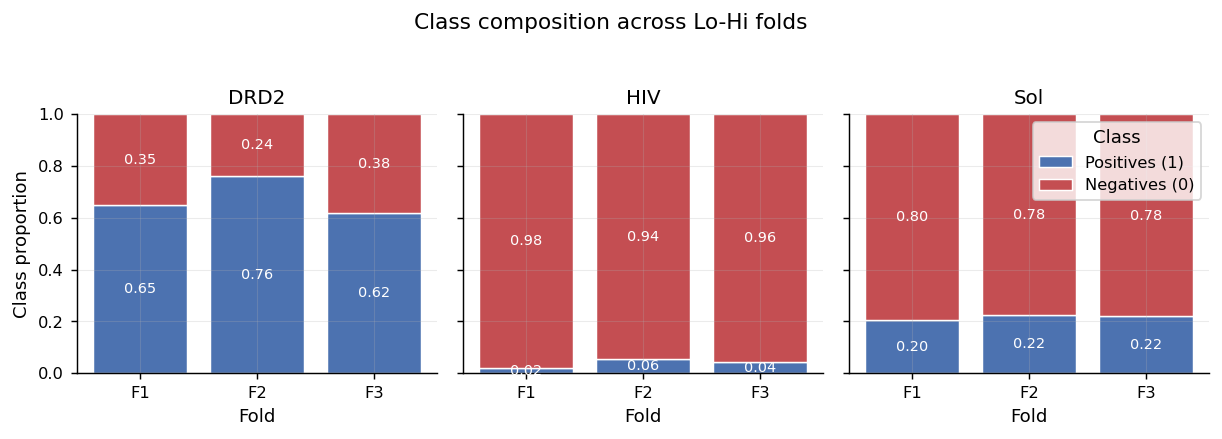

In [4]:
rows = []

for ds in DATASETS:
    for fold, fname in SUBSET_FILES.items():
        df = pd.read_csv(PROJECT_ROOT / "data" / TASK / ds / fname)
        y = pd.to_numeric(df["value"], errors="coerce").dropna().astype(int)

        rows.append(
            {
                "dataset": ds,
                "dataset_label": DATASET_LABELS[ds],
                "fold": fold,
                "n": len(y),
                "positive_rate": (y == 1).mean(),
                "negative_rate": (y == 0).mean(),
            }
        )

class_balance = pd.DataFrame(rows)
class_balance["fold"] = pd.Categorical(
    class_balance["fold"], categories=FOLDS, ordered=True
)
class_balance = class_balance.sort_values(["dataset", "fold"])

display(class_balance)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2), sharey=True)

pos_color = "#4C72B0"
neg_color = "#C44E52"

for ax, ds in zip(axes, DATASET_ORDER):
    sub = class_balance[class_balance["dataset"] == ds].sort_values("fold")
    x = np.arange(len(sub))

    ax.bar(
        x,
        sub["positive_rate"],
        color=pos_color,
        edgecolor="white",
        linewidth=0.8,
        label="Positives (1)",
    )

    ax.bar(
        x,
        sub["negative_rate"],
        bottom=sub["positive_rate"],
        color=neg_color,
        edgecolor="white",
        linewidth=0.8,
        label="Negatives (0)",
    )

    ax.set_title(DATASET_LABELS[ds])
    ax.set_xticks(x)
    ax.set_xticklabels(sub["fold"].astype(str))
    ax.set_xlabel("Fold")
    ax.set_ylim(0, 1)

    for xi, pos, neg in zip(x, sub["positive_rate"], sub["negative_rate"]):
        ax.text(
            xi,
            pos / 2,
            f"{pos:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
        )
        ax.text(
            xi,
            pos + neg / 2,
            f"{neg:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
        )

    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Class proportion")
axes[-1].legend(title="Class", frameon=True, loc="upper right")

fig.suptitle("Class composition across Lo-Hi folds", y=1.04)
fig.tight_layout()

save_fig(fig, "fig1_class_composition_by_fold")
plt.show()

## Activity-rule stability across folds

Here the question is whether the model learns the same activity rule across the three Lo-Hi folds. I use RBO as the primary metric because it is top-weighted and more appropriate for sparse feature rankings. I also report top-k Jaccard similarity as an order-insensitive feature-set stability measure.

High RBO means the top activity features are stable across folds. Low RBO is compatible with rule instability, but I do not interpret it as direct proof of concept shift.

Regola stabile tra fold → il modello usa più o meno gli stessi bit/feature → lo shift può essere più compatibile con covariate shift

Regola instabile tra fold → il modello cambia le feature importanti da fold a fold → può indicare instabilità della relazione feature → activity → compatibile con possibile concept / conditional shift

Rank-Biased Overlap --> perchè ci interessano di più i top bit, non se il bit 1800 e bit 1900 si scambiano La domanda è le feature più importanti per il modello sono stabili tra fold? e non tutti i 2048 bit sono ordinati nello stesso identico modo?

Before asking whether OOD validation improves model selection, I check whether the activity rule itself is stable across Lo-Hi folds. If the top-ranked activity features remain similar across folds, then the model is learning a stable rule under distribution shift. If the rankings change substantially, then the shift may involve instability in the learned feature-activity relationship.


In [ ]:
from scipy.spatial.distance import jaccard as scipy_jaccard


def importance_for_model(df: pd.DataFrame, model: str) -> pd.Series:
    # DT uses tree importance; linear models use coefficient magnitude
    if model == "DT" and "tree_importance" in df.columns:
        return (
            pd.to_numeric(df["tree_importance"], errors="coerce")
            .fillna(0.0)
            .clip(lower=0.0)
        )

    for c in [
        "normalized_abs_importance",
        "abs_weight",
        "importance_value",
        "coefficient",
    ]:
        if c in df.columns:
            v = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
            return v.abs()

    raise ValueError(f"No usable importance column for model={model}")


def ranking_list(
    df: pd.DataFrame,
    dataset: str,
    model: str,
    fold: int,
    protocol: str = "ood",
) -> list[int]:
    sub = df[
        (df["dataset"] == dataset)
        & (df["model"] == model)
        & (df["fold"].astype(int) == int(fold))
        & (df["protocol_norm"] == protocol)
    ].copy()

    if sub.empty:
        return []

    sub["rank_importance"] = importance_for_model(sub, model)
    sub = sub[sub["rank_importance"] > 0].copy()

    sub["feature_idx"] = sub["feature_idx"].astype(int)

    sub = sub.sort_values(
        ["rank_importance", "feature_idx"],
        ascending=[False, True],
    )

    return sub["feature_idx"].tolist()


def rbo_score(
    s: list[int],
    t: list[int],
    p: float = 0.90,
    depth: int | None = None,
) -> float:
    # Finite-depth RBO top-weighted ranking overlap
    if depth is None:
        depth = max(len(s), len(t))

    if depth == 0:
        return np.nan

    s_seen, t_seen = set(), set()
    score = 0.0

    for d in range(1, depth + 1):
        if d <= len(s):
            s_seen.add(s[d - 1])
        if d <= len(t):
            t_seen.add(t[d - 1])

        agreement = len(s_seen & t_seen) / d
        score += agreement * (p ** (d - 1))

    return float((1 - p) * score)


def topk_jaccard_similarity(s: list[int], t: list[int], k: int = 100) -> float:
    s_top = set(s[:k])
    t_top = set(t[:k])

    universe = sorted(s_top | t_top)

    if len(universe) == 0:
        return np.nan

    s_vec = np.array([feature in s_top for feature in universe], dtype=bool)
    t_vec = np.array([feature in t_top for feature in universe], dtype=bool)

    # scipy_jaccard returns distance, so similarity is 1 - distance
    return float(1.0 - scipy_jaccard(s_vec, t_vec))


def build_ranking_stability(
    feature_df: pd.DataFrame,
    top_k: int = 100,
    p: float = 0.90,
) -> pd.DataFrame:
    rows = []

    for ds in DATASETS:
        for model in RANKING_MODELS:
            ranks = {
                fold: ranking_list(
                    feature_df,
                    dataset=ds,
                    model=model,
                    fold=i + 1,
                    protocol="ood",
                )
                for i, fold in enumerate(FOLDS)
            }

            for fa, fb in combinations(FOLDS, 2):
                s, t = ranks[fa], ranks[fb]

                rows.append(
                    {
                        "dataset": ds,
                        "dataset_label": DATASET_LABELS[ds],
                        "model": model,
                        "fold_a": fa,
                        "fold_b": fb,
                        "pair": f"{fa}_vs_{fb}",
                        # Top-k ranking / set stability
                        "rbo": rbo_score(
                            s[:top_k],
                            t[:top_k],
                            p=p,
                            depth=top_k,
                        ),
                        "jaccard_similarity_topk": topk_jaccard_similarity(
                            s,
                            t,
                            k=top_k,
                        ),
                        # List-size diagnostics
                        "n_pos_a": len(s),
                        "n_pos_b": len(t),
                        "min_pair_positive_features": min(len(s), len(t)),
                        "max_pair_positive_features": max(len(s), len(t)),
                        "top_k": top_k,
                        "rbo_p": p,
                    }
                )

    pairwise = pd.DataFrame(rows)

    summary = (
        pairwise.groupby(["dataset", "dataset_label", "model"], as_index=False)
        .agg(
            mean_rbo=("rbo", "mean"),
            std_rbo=("rbo", "std"),
            mean_jaccard_similarity=("jaccard_similarity_topk", "mean"),
            std_jaccard_similarity=("jaccard_similarity_topk", "std"),
            min_positive_features=("min_pair_positive_features", "min"),
            max_positive_features=("max_pair_positive_features", "max"),
        )
        .sort_values(["dataset", "model"])
    )

    pairwise.to_csv(
        TAB_DIR / "tab2_ranking_stability_pairwise.csv",
        index=False,
    )

    summary.to_csv(
        TAB_DIR / "tab2_ranking_stability_summary.csv",
        index=False,
    )

    return pairwise, summary


rank_pairwise, tab2_ranking_stability = build_ranking_stability(
    feature_importance,
    top_k=100,
    p=0.90,
)

display(tab2_ranking_stability)

In [ ]:
def fig_ranking_stability(summary: pd.DataFrame, top_k: int = 100) -> None:
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        summary = summary.copy()

        row_order = [DATASET_LABELS[d] for d in DATASET_ORDER]
        col_order = [m for m in RANKING_MODELS if m in summary["model"].unique()]

        rbo_mat = summary.pivot(
            index="dataset_label", columns="model", values="mean_rbo"
        ).reindex(index=row_order, columns=col_order)

        jaccard_mat = summary.pivot(
            index="dataset_label", columns="model", values="mean_jaccard_similarity"
        ).reindex(index=row_order, columns=col_order)

        fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))

        panels = [
            (
                axes[0],
                rbo_mat,
                "Mean RBO",
                "viridis",
                "Top-weighted ranking overlap\nhigher = more stable",
            ),
            (
                axes[1],
                jaccard_mat,
                "Mean Jaccard similarity",
                "YlOrBr",
                "Top-k feature-set overlap\nhigher = more stable",
            ),
        ]

        for ax, mat, title, cmap, cbar_label in panels:
            values = mat.values.astype(float)

            im = ax.imshow(
                values,
                cmap=cmap,
                vmin=0.0,
                vmax=1.0,
                aspect="auto",
            )

            ax.set_title(title, pad=12)

            ax.set_xticks(np.arange(mat.shape[1]))
            ax.set_xticklabels(mat.columns)

            ax.set_yticks(np.arange(mat.shape[0]))
            ax.set_yticklabels(mat.index)

            for i in range(mat.shape[0]):
                for j in range(mat.shape[1]):
                    v = mat.iloc[i, j]

                    if pd.isna(v):
                        txt = "NA"
                        color = "black"
                    else:
                        txt = f"{v:.2f}"
                        if title == "Mean Jaccard similarity":
                            color = "white" if v > 0.55 else "black"
                        else:
                            color = "white" if v < 0.45 else "black"

                    ax.text(
                        j,
                        i,
                        txt,
                        ha="center",
                        va="center",
                        fontsize=11,
                        fontweight="bold",
                        color=color,
                    )

            ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
            ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.5)

            ax.tick_params(which="minor", bottom=False, left=False)
            ax.tick_params(which="major", bottom=False, left=False)
            ax.spines[["top", "right", "bottom", "left"]].set_visible(False)

            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label(cbar_label, labelpad=10)
            cbar.outline.set_visible(False)

        fig.suptitle(
            f"Fold-to-fold activity-rule stability across models — top-{top_k} features",
            fontweight="bold",
            fontsize=15,
            y=1.02,
        )

        fig.tight_layout()

        save_fig(fig, "fig2_ranking_stability_rbo_jaccard_top100")

        plt.show()
        plt.close(fig)


fig_ranking_stability(tab2_ranking_stability, top_k=100)

## Covariate localization: full ECFP4 fold distance

As a first reference, I inspect the fold-to-fold Tanimoto distance in the full ECFP4 space.
This gives the baseline geometric separation between folds before restricting the representation to activity-relevant bits.


In [ ]:
def fig_full_fold_distance_heatmap(dist_df: pd.DataFrame) -> None:
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        full_df = dist_df[dist_df["bit_source"] == "full_ecfp4"].copy()

        if full_df.empty:
            return

        full_df = full_df.drop_duplicates(["dataset", "dataset_label", "pair"])

        pair_order = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]
        pair_labels = ["F1 vs F2", "F1 vs F3", "F2 vs F3"]
        row_order = [DATASET_LABELS[d] for d in DATASET_ORDER]

        mat = full_df.pivot(
            index="dataset_label", columns="pair", values="pairwise_distance_mean"
        ).reindex(index=row_order, columns=pair_order)

        vals = mat.values.astype(float)
        vmin = np.nanmin(vals)
        vmax = np.nanmax(vals)

        fig, ax = plt.subplots(figsize=(6, 4))

        im = ax.imshow(
            vals,
            cmap="YlOrRd",
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
        )

        ax.set_xticks(np.arange(len(pair_order)))
        ax.set_xticklabels(pair_labels)
        ax.set_yticks(np.arange(len(row_order)))
        ax.set_yticklabels(row_order)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat.iloc[i, j]
                txt = "NA" if pd.isna(v) else f"{v:.3f}"
                color = "white" if pd.notna(v) and v > (vmin + vmax) / 2 else "black"
                ax.text(j, i, txt, ha="center", va="center", color=color)

        ax.set_title("Full ECFP4 fold distance", fontweight="bold", pad=12)
        ax.set_xlabel("Fold pair", labelpad=8)
        ax.set_ylabel("Dataset", labelpad=8)

        ax.set_xticks(np.arange(-0.5, len(pair_order), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(row_order), 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.5)

        ax.tick_params(which="minor", bottom=False, left=False)
        ax.tick_params(which="major", bottom=False, left=False)

        ax.spines[["top", "right", "bottom", "left"]].set_visible(False)

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Pairwise Tanimoto distance", labelpad=10)
        cbar.outline.set_visible(False)

        fig.tight_layout()

        save_fig(fig, "fig3a_full_ecfp4_fold_distance_heatmap")
        plt.show()


fig_full_fold_distance_heatmap(tanimoto_summary)

## Activity-restricted fold distance vs k

I now compare the fold distance measured in activity-relevant subspaces.
For each dataset and model, I show how the mean pairwise Tanimoto distance evolves as I increase the number of selected ECFP4 bits.

The dotted horizontal lines indicate the corresponding full-ECFP4 fold distance for the same fold pair.


In [ ]:
def fig_activity_restricted_distance_by_source(
    dist_df: pd.DataFrame,
    bit_source: str,
    source_label: str,
) -> None:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    from matplotlib.lines import Line2D
    import numpy as np
    import pandas as pd

    df = dist_df.copy()
    df["k"] = pd.to_numeric(df["k"], errors="coerce")

    k_plot = [20, 50, 100, 150, 200]

    model_order = [m for m in ALL_MODELS if m in df["model"].unique()]
    dataset_order = [d for d in DATASET_ORDER if d in df["dataset"].unique()]

    pair_order = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]

    pair_colors = {
        "F1_vs_F2": "#4C78A8",
        "F1_vs_F3": "#F58518",
        "F2_vs_F3": "#54A24B",
    }

    if bit_source == "activity_ood":
        pair_labels = {
            "F1_vs_F2": "F1 inner train → F2 inner val → F3 outer test",
            "F1_vs_F3": "F1 inner train → F3 inner val → F2 outer test",
            "F2_vs_F3": "F2 inner train → F3 inner val → F1 outer test",
        }
        legend_title = "OOD holdout protocol"

    else:
        pair_labels = {
            "F1_vs_F2": "F1 + F2 outer train → F3 outer test",
            "F1_vs_F3": "F1 + F3 outer train → F2 outer test",
            "F2_vs_F3": "F2 + F3 outer train → F1 outer test",
        }
        legend_title = "Random-shuffle protocol"

    # Global y-limits for the whole figure
    plot_scope = df[
        (df["bit_source"] == bit_source)
        & (df["k"].isin(k_plot))
        & (df["dataset"].isin(dataset_order))
        & (df["model"].isin(model_order))
    ].copy()

    y_values = (
        pd.to_numeric(plot_scope["pairwise_distance_mean"], errors="coerce")
        .dropna()
        .tolist()
    )

    if "full_pairwise_distance_mean" in plot_scope.columns:
        y_values += (
            pd.to_numeric(plot_scope["full_pairwise_distance_mean"], errors="coerce")
            .dropna()
            .tolist()
        )

    if len(y_values) == 0:
        raise ValueError(
            f"No valid distance values found for bit_source={bit_source!r}."
        )

    y_min = max(0.0, float(np.nanmin(y_values)) - 0.03)
    y_max = min(1.0, float(np.nanmax(y_values)) + 0.03)

    fig, axes = plt.subplots(
        len(dataset_order),
        len(model_order),
        figsize=(4.2 * len(model_order), 3.2 * len(dataset_order)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for i, ds in enumerate(dataset_order):
        for j, model in enumerate(model_order):
            ax = axes[i, j]

            sub_all = df[
                (df["dataset"] == ds)
                & (df["model"] == model)
                & (df["bit_source"] == bit_source)
                & (df["k"].isin(k_plot))
            ].copy()

            # One single full-ECFP4 reference per panel.
            # It is the mean full-ECFP4 distance across the three fold pairs.
            if "full_pairwise_distance_mean" in sub_all.columns:
                full_ref_panel = pd.to_numeric(
                    sub_all.drop_duplicates("pair")["full_pairwise_distance_mean"],
                    errors="coerce",
                ).dropna()

                if len(full_ref_panel) > 0:
                    ax.axhline(
                        float(full_ref_panel.mean()),
                        ls=":",
                        lw=1.15,
                        color="0.30",
                        alpha=0.55,
                        zorder=1,
                    )

            for pair in pair_order:
                sub = sub_all[sub_all["pair"] == pair].sort_values("k")

                if sub.empty:
                    continue

                ax.plot(
                    sub["k"].astype(int),
                    sub["pairwise_distance_mean"],
                    marker="o",
                    markersize=4.2,
                    lw=1.55,
                    color=pair_colors[pair],
                    label=pair_labels[pair],
                    zorder=3,
                )

            ax.set_xscale("log")
            ax.set_xticks(k_plot)
            ax.set_xticklabels([str(k) for k in k_plot], rotation=35)

            ax.set_ylim(y_min, y_max)
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

            ax.grid(ls="--", alpha=0.32)

            if i == 0:
                ax.set_title(
                    MODEL_LABELS.get(model, model),
                    fontweight="bold",
                    pad=8,
                )

            if j == 0:
                ax.set_ylabel(
                    f"{DATASET_LABELS.get(ds, ds)}\nPairwise distance",
                    fontweight="bold",
                )

            if i == len(dataset_order) - 1:
                ax.set_xlabel("Top-k ECFP4 bits")

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    handles = [
        Line2D(
            [0],
            [0],
            color=pair_colors[pair],
            marker="o",
            lw=2.0,
            markersize=5,
            label=pair_labels[pair],
        )
        for pair in pair_order
    ]

    full_handle = Line2D(
        [0],
        [0],
        color="0.30",
        lw=1.3,
        linestyle=":",
        label="Mean full ECFP4 reference",
    )

    fig.legend(
        handles=handles + [full_handle],
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.035),
        title=legend_title,
        fontsize=8.0,
        title_fontsize=8.7,
    )

    fig.suptitle(
        f"Activity-restricted fold distance vs k — {source_label}",
        y=1.085,
        fontweight="bold",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    safe_name = bit_source.replace("activity_", "").replace("_shuffle", "")

    save_fig(
        fig,
        f"fig3b_activity_restricted_distance_{safe_name}_models_columns",
    )

    plt.show()
    plt.close(fig)


fig_activity_restricted_distance_by_source(
    tanimoto_summary,
    bit_source="activity_ood",
    source_label="OOD activity bits",
)

fig_activity_restricted_distance_by_source(
    tanimoto_summary,
    bit_source="activity_random_shuffle",
    source_label="Random-shuffle activity bits",
)

In [ ]:
def build_step3a_recap_table(dist_df: pd.DataFrame, top_k: int = 100) -> pd.DataFrame:
    sources = {
        "activity_ood": "activity_ood",
        "activity_random_shuffle": "activity_random",
        "dataset_detection": "fold_discriminator",
    }

    df = dist_df.copy()
    df["k"] = df["k"].astype(int)

    # Full ECFP4 is model-independent, so keep one copy per dataset/pair
    full = (
        df[df["bit_source"] == "full_ecfp4"]
        .drop_duplicates(["dataset", "dataset_label", "pair"])
        .groupby(["dataset", "dataset_label"], as_index=False)
        .agg(full_ecfp4_distance=("pairwise_distance_mean", "mean"))
    )

    # Random bits are also model-independent in the output, so keep one copy per dataset/pair/k
    random_bits = (
        df[(df["bit_source"] == "random_bits") & (df["k"] == top_k)]
        .drop_duplicates(["dataset", "dataset_label", "pair"])
        .groupby(["dataset", "dataset_label"], as_index=False)
        .agg(random_bits_distance=("pairwise_distance_mean", "mean"))
    )

    sub = df[(df["k"] == top_k) & (df["bit_source"].isin(sources.keys()))].copy()

    sub["source"] = sub["bit_source"].map(sources)

    recap_long = sub.groupby(
        ["dataset", "dataset_label", "model", "source"], as_index=False
    ).agg(
        distance=("pairwise_distance_mean", "mean"),
        bits_used=("bits_used_mean", "mean"),
        valid_fraction=("valid_molecule_fraction_mean", "mean"),
        main_safe_pairs=("high_coverage_recommended_for_main_plot", "sum"),
    )

    distance_wide = recap_long.pivot(
        index=["dataset", "dataset_label", "model"], columns="source", values="distance"
    ).reset_index()

    bits_wide = recap_long.pivot(
        index=["dataset", "dataset_label", "model"],
        columns="source",
        values="bits_used",
    ).reset_index()

    bits_wide = bits_wide.rename(
        columns={c: f"{c}_bits" for c in sources.values() if c in bits_wide.columns}
    )

    safe_wide = recap_long.pivot(
        index=["dataset", "dataset_label", "model"],
        columns="source",
        values="main_safe_pairs",
    ).reset_index()

    safe_wide = safe_wide.rename(
        columns={
            c: f"{c}_safe_pairs" for c in sources.values() if c in safe_wide.columns
        }
    )

    tab = (
        distance_wide.merge(
            bits_wide, on=["dataset", "dataset_label", "model"], how="left"
        )
        .merge(safe_wide, on=["dataset", "dataset_label", "model"], how="left")
        .merge(full, on=["dataset", "dataset_label"], how="left")
        .merge(random_bits, on=["dataset", "dataset_label"], how="left")
    )

    tab["activity_ood_minus_full"] = tab["activity_ood"] - tab["full_ecfp4_distance"]
    tab["activity_ood_minus_random_bits"] = (
        tab["activity_ood"] - tab["random_bits_distance"]
    )
    tab["fold_discriminator_minus_full"] = (
        tab["fold_discriminator"] - tab["full_ecfp4_distance"]
    )

    tab["dataset"] = pd.Categorical(
        tab["dataset"], categories=DATASET_ORDER, ordered=True
    )
    tab["model"] = pd.Categorical(tab["model"], categories=ALL_MODELS, ordered=True)

    tab = tab.sort_values(["dataset", "model"]).reset_index(drop=True)

    numeric_cols = tab.select_dtypes(include="number").columns
    tab[numeric_cols] = tab[numeric_cols].round(4)

    tab.to_csv(
        TAB_DIR / f"tab3a_covariate_localization_recap_top{top_k}.csv", index=False
    )

    return tab


tab3a_covariate_localization = build_step3a_recap_table(tanimoto_summary, top_k=100)
display(tab3a_covariate_localization)

In [ ]:
def compute_ecfp4_matrix_from_smiles(
    smiles: pd.Series,
    n_bits: int = 2048,
) -> np.ndarray:
    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=2,
        fpSize=n_bits,
    )

    fps = []
    n_invalid = 0

    for smi in smiles.astype(str):
        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            n_invalid += 1
            continue

        arr = np.zeros((n_bits,), dtype=np.uint8)
        fp = generator.GetFingerprint(mol)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fps.append(arr)

    if n_invalid > 0:
        print(
            f"Removed {n_invalid} invalid SMILES in activity-union ECFP4 computation."
        )

    return np.asarray(fps, dtype=np.uint8)

In [ ]:
def compute_ecfp4_matrix_from_smiles(
    smiles: pd.Series,
    n_bits: int = 2048,
) -> np.ndarray:
    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=2,
        fpSize=n_bits,
    )

    fps = []
    n_invalid = 0

    for smi in smiles.astype(str):
        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            n_invalid += 1
            continue

        arr = np.zeros((n_bits,), dtype=np.uint8)
        fp = generator.GetFingerprint(mol)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fps.append(arr)

    if n_invalid > 0:
        print(
            f"Removed {n_invalid} invalid SMILES in activity-union ECFP4 computation."
        )

    return np.asarray(fps, dtype=np.uint8)

In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def detect_smiles_column(df: pd.DataFrame) -> str:
    candidates = [
        "smiles",
        "SMILES",
        "canonical_smiles",
        "canonical_smile",
        "mol_smiles",
        "molecule_smiles",
        "compound_smiles",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    raise ValueError(
        f"Could not detect SMILES column. Available columns: {df.columns.tolist()}"
    )


def compute_ecfp4_matrix_from_smiles(
    smiles: pd.Series,
    n_bits: int = 2048,
) -> np.ndarray:
    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=2,
        fpSize=n_bits,
    )

    fps = []
    n_invalid = 0

    for smi in smiles.astype(str):
        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            n_invalid += 1
            continue

        arr = np.zeros((n_bits,), dtype=np.uint8)
        fp = generator.GetFingerprint(mol)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fps.append(arr)

    if n_invalid > 0:
        print(
            f"Removed {n_invalid} invalid SMILES in activity-union ECFP4 computation."
        )

    return np.asarray(fps, dtype=np.uint8)


def load_fold_ecfp4_matrices(
    dataset: str,
    n_bits: int = 2048,
) -> dict[str, np.ndarray]:
    fold_mats = {}

    for fold, fname in SUBSET_FILES.items():
        path = PROJECT_ROOT / "data" / TASK / dataset / fname
        df_fold = pd.read_csv(path)

        smiles_col = detect_smiles_column(df_fold)

        fold_mats[fold] = compute_ecfp4_matrix_from_smiles(
            df_fold[smiles_col],
            n_bits=n_bits,
        )

    return fold_mats


def importance_for_model_union(df: pd.DataFrame, model: str) -> pd.Series:
    # DT: tree_importance
    if model == "DT" and "tree_importance" in df.columns:
        return (
            pd.to_numeric(df["tree_importance"], errors="coerce")
            .fillna(0.0)
            .clip(lower=0.0)
        )

    # Linear models: absolute coefficient
    for c in [
        "normalized_abs_importance",
        "abs_weight",
        "importance_value",
        "coefficient",
        "raw_weight",
    ]:
        if c in df.columns:
            return pd.to_numeric(df[c], errors="coerce").fillna(0.0).abs()

    raise ValueError(f"No usable importance column for model={model}")


def get_activity_feature_union(
    feature_df: pd.DataFrame,
    dataset: str,
    model: str,
    protocol: str,
    top_k: int = 100,
) -> list[int]:
    protocol = normalize_protocol(protocol)

    sub = feature_df[
        (feature_df["dataset"] == dataset)
        & (feature_df["model"].map(normalize_model) == model)
    ].copy()

    if "protocol_norm" not in sub.columns:
        sub["protocol_norm"] = sub["protocol"].map(normalize_protocol)

    sub = sub[sub["protocol_norm"] == protocol].copy()

    if sub.empty:
        return []

    features = set()

    for fold in [1, 2, 3]:
        fold_sub = sub[sub["fold"].astype(int) == fold].copy()

        if fold_sub.empty:
            continue

        fold_sub["rank_importance"] = importance_for_model_union(fold_sub, model)
        fold_sub = fold_sub[fold_sub["rank_importance"] > 0].copy()

        if fold_sub.empty:
            continue

        fold_sub["feature_idx"] = fold_sub["feature_idx"].astype(int)

        fold_sub = fold_sub.sort_values(
            ["rank_importance", "feature_idx"],
            ascending=[False, True],
        )

        features.update(fold_sub["feature_idx"].head(top_k).tolist())

    features = sorted([f for f in features if 0 <= int(f) < 2048])

    return features


def mean_pairwise_tanimoto_similarity(
    A: np.ndarray,
    B: np.ndarray,
    selected_bits: list[int],
    chunk_size: int = 512,
) -> dict:
    if len(selected_bits) == 0:
        return {
            "mean_similarity": np.nan,
            "mean_distance": np.nan,
            "valid_fraction_a": np.nan,
            "valid_fraction_b": np.nan,
            "n_valid_a": 0,
            "n_valid_b": 0,
        }

    A_sub = A[:, selected_bits].astype(np.uint8, copy=False)
    B_sub = B[:, selected_bits].astype(np.uint8, copy=False)

    A_sum = A_sub.sum(axis=1).astype(np.int32)
    B_sum = B_sub.sum(axis=1).astype(np.int32)

    valid_a = A_sum > 0
    valid_b = B_sum > 0

    A_sub = A_sub[valid_a]
    B_sub = B_sub[valid_b]

    A_sum = A_sum[valid_a]
    B_sum = B_sum[valid_b]

    n_valid_a = A_sub.shape[0]
    n_valid_b = B_sub.shape[0]

    valid_fraction_a = n_valid_a / A.shape[0] if A.shape[0] > 0 else np.nan
    valid_fraction_b = n_valid_b / B.shape[0] if B.shape[0] > 0 else np.nan

    if n_valid_a == 0 or n_valid_b == 0:
        return {
            "mean_similarity": np.nan,
            "mean_distance": np.nan,
            "valid_fraction_a": valid_fraction_a,
            "valid_fraction_b": valid_fraction_b,
            "n_valid_a": n_valid_a,
            "n_valid_b": n_valid_b,
        }

    B_T = B_sub.T.astype(np.uint16, copy=False)

    total_similarity = 0.0
    total_pairs = 0

    for start in range(0, n_valid_a, chunk_size):
        stop = min(start + chunk_size, n_valid_a)

        A_chunk = A_sub[start:stop].astype(np.uint16, copy=False)
        A_chunk_sum = A_sum[start:stop]

        intersection = A_chunk @ B_T

        union = A_chunk_sum[:, None] + B_sum[None, :] - intersection

        sim = intersection / union

        total_similarity += float(sim.sum())
        total_pairs += sim.size

    mean_similarity = total_similarity / total_pairs
    mean_distance = 1.0 - mean_similarity

    return {
        "mean_similarity": mean_similarity,
        "mean_distance": mean_distance,
        "valid_fraction_a": valid_fraction_a,
        "valid_fraction_b": valid_fraction_b,
        "n_valid_a": n_valid_a,
        "n_valid_b": n_valid_b,
    }

In [ ]:
def build_activity_union_tanimoto_table(
    feature_df: pd.DataFrame,
    full_distance_df: pd.DataFrame,
    top_k: int = 100,
    protocols=("ood", "random"),
) -> pd.DataFrame:
    rows = []

    fold_pairs = {
        "F1_vs_F2": ("F1", "F2"),
        "F1_vs_F3": ("F1", "F3"),
        "F2_vs_F3": ("F2", "F3"),
    }

    full_ref = full_distance_df[full_distance_df["bit_source"] == "full_ecfp4"].copy()

    full_ref = full_ref.drop_duplicates(["dataset", "pair"])[
        ["dataset", "pair", "pairwise_distance_mean"]
    ].rename(columns={"pairwise_distance_mean": "full_ecfp4_distance"})

    full_ref["full_ecfp4_similarity"] = 1.0 - full_ref["full_ecfp4_distance"]

    for ds in DATASET_ORDER:
        print(f"\nDataset: {DATASET_LABELS.get(ds, ds)}")

        fold_mats = load_fold_ecfp4_matrices(ds, n_bits=2048)

        for model in MODEL_ORDER:
            for protocol in protocols:
                protocol_norm = normalize_protocol(protocol)

                selected_bits = get_activity_feature_union(
                    feature_df,
                    dataset=ds,
                    model=model,
                    protocol=protocol_norm,
                    top_k=top_k,
                )

                print(
                    f"  {model} | {protocol_norm} | "
                    f"union top-{top_k} bits = {len(selected_bits)}"
                )

                for pair_name, (fa, fb) in fold_pairs.items():
                    stats = mean_pairwise_tanimoto_similarity(
                        fold_mats[fa],
                        fold_mats[fb],
                        selected_bits=selected_bits,
                        chunk_size=512,
                    )

                    full_row = full_ref[
                        (full_ref["dataset"] == ds) & (full_ref["pair"] == pair_name)
                    ]

                    if full_row.empty:
                        full_distance = np.nan
                        full_similarity = np.nan
                    else:
                        full_distance = float(full_row["full_ecfp4_distance"].iloc[0])
                        full_similarity = float(
                            full_row["full_ecfp4_similarity"].iloc[0]
                        )

                    restricted_similarity = stats["mean_similarity"]
                    restricted_distance = stats["mean_distance"]

                    rows.append(
                        {
                            "dataset": ds,
                            "dataset_label": DATASET_LABELS.get(ds, ds),
                            "model": model,
                            "protocol": protocol_norm,
                            "protocol_label": PROTOCOL_LABELS.get(
                                protocol_norm,
                                protocol_norm,
                            ),
                            "pair": pair_name,
                            "fold_a": fa,
                            "fold_b": fb,
                            "top_k_per_fold": top_k,
                            "n_union_bits": len(selected_bits),
                            "full_ecfp4_similarity": full_similarity,
                            "full_ecfp4_distance": full_distance,
                            "activity_union_similarity": restricted_similarity,
                            "activity_union_distance": restricted_distance,
                            "similarity_delta_restricted_minus_full": (
                                restricted_similarity - full_similarity
                                if pd.notna(restricted_similarity)
                                and pd.notna(full_similarity)
                                else np.nan
                            ),
                            "distance_delta_restricted_minus_full": (
                                restricted_distance - full_distance
                                if pd.notna(restricted_distance)
                                and pd.notna(full_distance)
                                else np.nan
                            ),
                            "valid_fraction_fold_a": stats["valid_fraction_a"],
                            "valid_fraction_fold_b": stats["valid_fraction_b"],
                            "n_valid_fold_a": stats["n_valid_a"],
                            "n_valid_fold_b": stats["n_valid_b"],
                        }
                    )

    out = pd.DataFrame(rows)

    out["dataset"] = pd.Categorical(
        out["dataset"],
        categories=DATASET_ORDER,
        ordered=True,
    )

    out["model"] = pd.Categorical(
        out["model"],
        categories=MODEL_ORDER,
        ordered=True,
    )

    out["pair"] = pd.Categorical(
        out["pair"],
        categories=PAIR_ORDER,
        ordered=True,
    )

    out = out.sort_values(["dataset", "model", "protocol", "pair"]).reset_index(
        drop=True
    )

    numeric_cols = out.select_dtypes(include="number").columns
    out[numeric_cols] = out[numeric_cols].round(4)

    out.to_csv(
        TAB_DIR / f"tab3c_activity_union_tanimoto_top{top_k}.csv",
        index=False,
    )

    return out


activity_union_tanimoto_top100 = build_activity_union_tanimoto_table(
    feature_importance,
    tanimoto_summary,
    top_k=100,
    protocols=("ood", "random"),
)

display(activity_union_tanimoto_top100)

In [ ]:
def plot_activity_union_tanimoto_scatter(
    tab: pd.DataFrame,
    top_k: int = 100,
) -> None:
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from matplotlib.lines import Line2D

    df = tab.copy()

    df = df[
        df["full_ecfp4_similarity"].notna() & df["activity_union_similarity"].notna()
    ].copy()

    if df.empty:
        raise ValueError("No valid rows to plot.")

    with mpl.rc_context(
        {
            "font.size": 12,
            "axes.titlesize": 14,
            "axes.titleweight": "bold",
            "axes.labelsize": 12,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        datasets = [d for d in DATASET_ORDER if d in df["dataset"].unique()]

        fig, axes = plt.subplots(
            1,
            len(datasets),
            figsize=(14.5, 6.0),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

        protocol_colors = {
            "ood": "#2563EB",
            "random": "#DC2626",
        }

        model_markers = {
            "DT": "o",
            "LR": "s",
            "SVM": "^",
        }

        pair_alpha = {
            "F1_vs_F2": 0.95,
            "F1_vs_F3": 0.75,
            "F2_vs_F3": 0.55,
        }

        for j, ds in enumerate(datasets):
            ax = axes[0, j]

            sub = df[df["dataset"] == ds].copy()

            ax.axvline(
                0.4,
                color="#4B5563",
                linestyle=":",
                linewidth=1.5,
                zorder=1,
            )

            ax.axhline(
                0.4,
                color="#4B5563",
                linestyle=":",
                linewidth=1.5,
                zorder=1,
            )

            ax.plot(
                [0.0, 0.55],
                [0.0, 0.55],
                linestyle="--",
                color="#9CA3AF",
                linewidth=1.2,
                zorder=1,
            )

            for _, row in sub.iterrows():
                ax.scatter(
                    row["full_ecfp4_similarity"],
                    row["activity_union_similarity"],
                    color=protocol_colors.get(row["protocol"], "grey"),
                    marker=model_markers.get(row["model"], "o"),
                    s=130,
                    edgecolor="white",
                    linewidth=1.0,
                    alpha=pair_alpha.get(row["pair"], 0.8),
                    zorder=3,
                )

            ax.set_title(DATASET_LABELS.get(ds, ds), pad=14)

            ax.set_xlim(0.0, 0.55)
            ax.set_ylim(0.0, 0.55)

            ax.set_xlabel(
                "Full ECFP4 Tanimoto similarity", fontweight="bold", labelpad=10
            )

            if j == 0:
                ax.set_ylabel(
                    "Activity-union restricted\nTanimoto similarity",
                    fontweight="bold",
                    labelpad=10,
                )

            ax.grid(ls="--", alpha=0.4, color="lightgray", zorder=0)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_linewidth(1.2)
            ax.spines["bottom"].set_linewidth(1.2)

        protocol_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=color,
                markeredgecolor="white",
                markersize=10,
                label=PROTOCOL_LABELS.get(protocol, protocol),
            )
            for protocol, color in protocol_colors.items()
        ]

        model_handles = [
            Line2D(
                [0],
                [0],
                marker=marker,
                linestyle="",
                markerfacecolor="#6B7280",
                markeredgecolor="white",
                markersize=10,
                label=MODEL_LABELS.get(model, model),
            )
            for model, marker in model_markers.items()
        ]

        threshold_handle = Line2D(
            [0],
            [0],
            color="#4B5563",
            linestyle=":",
            linewidth=1.8,
            label="0.4 reference, not mean-similarity criterion",
        )

        diagonal_handle = Line2D(
            [0],
            [0],
            color="#9CA3AF",
            linestyle="--",
            linewidth=1.5,
            label="Restricted = full",
        )

        fig.legend(
            handles=protocol_handles
            + model_handles
            + [threshold_handle, diagonal_handle],
            loc="lower center",
            ncol=4,
            frameon=False,
            bbox_to_anchor=(0.5, 0.02),
            fontsize=11,
            columnspacing=2.0,
            handletextpad=0.6,
        )

        fig.suptitle(
            f"Full vs activity-union restricted Tanimoto similarity — top-{top_k}",
            fontweight="bold",
            fontsize=16,
            y=0.96,
        )

        fig.subplots_adjust(bottom=0.22, top=0.86, wspace=0.15)

        save_fig(
            fig,
            f"fig3c_full_vs_activity_union_tanimoto_similarity_top{top_k}",
        )

        plt.show()
        plt.close(fig)


plot_activity_union_tanimoto_scatter(
    activity_union_tanimoto_top100,
    top_k=100,
)

In [ ]:
def build_activity_union_tanimoto_recap(
    tab: pd.DataFrame,
    top_k: int = 100,
) -> pd.DataFrame:
    df = tab.copy()

    recap = df.groupby(
        ["dataset", "dataset_label", "model", "protocol", "protocol_label"],
        as_index=False,
    ).agg(
        mean_full_similarity=("full_ecfp4_similarity", "mean"),
        mean_activity_union_similarity=("activity_union_similarity", "mean"),
        mean_similarity_delta=(
            "similarity_delta_restricted_minus_full",
            "mean",
        ),
        mean_full_distance=("full_ecfp4_distance", "mean"),
        mean_activity_union_distance=("activity_union_distance", "mean"),
        mean_distance_delta=(
            "distance_delta_restricted_minus_full",
            "mean",
        ),
        mean_union_bits=("n_union_bits", "mean"),
        min_valid_fraction_a=("valid_fraction_fold_a", "min"),
        min_valid_fraction_b=("valid_fraction_fold_b", "min"),
    )

    recap["dataset"] = pd.Categorical(
        recap["dataset"],
        categories=DATASET_ORDER,
        ordered=True,
    )

    recap["model"] = pd.Categorical(
        recap["model"],
        categories=MODEL_ORDER,
        ordered=True,
    )

    recap["protocol"] = pd.Categorical(
        recap["protocol"],
        categories=["ood", "random"],
        ordered=True,
    )

    recap = recap.sort_values(["dataset", "model", "protocol"]).reset_index(drop=True)

    numeric_cols = recap.select_dtypes(include="number").columns
    recap[numeric_cols] = recap[numeric_cols].round(4)

    recap.to_csv(
        TAB_DIR / f"tab3c_activity_union_tanimoto_recap_top{top_k}.csv",
        index=False,
    )

    return recap


tab3c_activity_union_tanimoto_recap = build_activity_union_tanimoto_recap(
    activity_union_tanimoto_top100,
    top_k=100,
)

display(tab3c_activity_union_tanimoto_recap)

In [ ]:
from matplotlib.lines import Line2D


def get_protocol_summary() -> pd.DataFrame:
    needed = {
        "dataset",
        "model",
        "protocol",
        "fingerprint",
        "train_mean",
        "inner_mean",
        "test_mean",
    }

    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame) and needed.issubset(obj.columns):
            print(f"Using dataframe already in memory: {name}")
            return obj.copy()

    search_dir = (
        PROJECT_ROOT
        / "results"
        / "results_ood_vs_random_shuffle"
        / "hi"
        / "cross_dataset"
    )

    for path in sorted(search_dir.glob("*.csv")):
        df = pd.read_csv(path)
        if needed.issubset(df.columns):
            print(f"Loaded summary from: {path.name}")
            return df.copy()

    raise ValueError("No summary table found.")


summary = protocol_summary.copy()

print("Protocols:", summary["protocol"].unique())
print("Models:", summary["model"].unique())
print("Fingerprints:", summary["fingerprint"].unique())

display(summary.head())

In [ ]:
def plot_metric_scatter_like_original(
    summary: pd.DataFrame,
    x_col: str,
    y_col: str,
    x_label: str,
    y_label: str,
    title: str,
    filename: str,
) -> None:
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from matplotlib.lines import Line2D

    try:
        from adjustText import adjust_text
    except ImportError as exc:
        raise ImportError(
            "This figure requires the adjustText package. Install it with: pip install adjustText"
        ) from exc

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        datasets = [d for d in DATASET_ORDER if d in summary["dataset"].unique()]
        n = len(datasets)

        fig, axes = plt.subplots(1, n, figsize=(5.0 * n, 5.0), squeeze=False)

        for idx, dataset in enumerate(datasets):
            ax = axes[0, idx]
            sub = summary[summary["dataset"] == dataset].copy()

            all_vals = pd.concat([sub[x_col], sub[y_col]]).dropna()
            lo = max(0.0, all_vals.min() - 0.05)
            hi = min(1.0, all_vals.max() + 0.05)
            lims = [lo, hi]

            ax.set_axisbelow(True)
            ax.grid(True, linestyle="--", color="lightgrey", alpha=0.6, zorder=0)

            ax.plot(lims, lims, ls="--", lw=1.2, color="#7f8c8d", zorder=1)

            ax.fill_between(
                lims, lims, [lims[0], lims[0]], alpha=0.03, color="#c0392b", zorder=0
            )

            for _, row in sub.iterrows():
                protocol = row["protocol"]
                model = row["model"]

                ax.scatter(
                    row[x_col],
                    row[y_col],
                    c=PROTOCOL_COLORS.get(protocol, "grey"),
                    marker=MODEL_MARKERS.get(model, "o"),
                    s=130,
                    edgecolors="white",
                    linewidths=1.2,
                    alpha=0.9,
                    zorder=3,
                )

            texts = []

            for _, row in sub.iterrows():
                ms = MODEL_SHORT.get(row["model"], str(row["model"])[:2])
                fp = str(row["fingerprint"]).lower()

                if "rdkit_desc" in fp or "rdkit desc" in fp:
                    fp_short = "R"
                elif "maccs" in fp:
                    fp_short = "M"
                elif "ecfp" in fp:
                    fp_short = "E"
                elif "topo" in fp:
                    fp_short = "T"
                else:
                    fp_short = str(row["fingerprint"])[:1].upper()

                label = f"{ms}"

                texts.append(
                    ax.text(
                        row[x_col],
                        row[y_col],
                        label,
                        fontsize=8,
                        fontweight="medium",
                        color="#222222",
                        zorder=4,
                    )
                )

            adjust_text(
                texts,
                ax=ax,
                force_text=(0.6, 0.8),
                force_points=(0.4, 0.5),
                arrowprops=dict(arrowstyle="-", color="dimgrey", lw=0.8, alpha=0.7),
            )

            ax.set_xlim(lims)
            ax.set_ylim(lims)
            ax.set_aspect("equal")

            ax.set_xlabel(x_label, labelpad=15)
            ax.set_ylabel(y_label, labelpad=8)

            ax.set_title(DATASET_LABELS.get(dataset, dataset), pad=12)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_linewidth(1.0)
            ax.spines["bottom"].set_linewidth(1.0)

        used_protocols = list(dict.fromkeys(summary["protocol"].tolist()))

        protocol_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=PROTOCOL_COLORS.get(p, "grey"),
                markersize=10,
                markeredgecolor="white",
                markeredgewidth=1.0,
                label=PROTOCOL_LABELS.get(p, p),
            )
            for p in used_protocols
        ]

        used_models = [m for m in MODEL_MARKERS if m in summary["model"].unique()]

        model_handles = [
            Line2D(
                [0],
                [0],
                marker=MODEL_MARKERS[m],
                color="w",
                markerfacecolor="grey",
                markersize=10,
                markeredgecolor="white",
                markeredgewidth=1.0,
                label=MODEL_SHORT.get(m, m),
            )
            for m in used_models
        ]

        fig.suptitle(title, fontsize=15, fontweight="bold", y=0.98)

        fig.legend(
            handles=protocol_handles + model_handles,
            loc="lower center",
            ncol=len(protocol_handles) + len(model_handles),
            fontsize=10,
            bbox_to_anchor=(0.5, -0.02),
            frameon=False,
            columnspacing=2.0,
            handletextpad=0.5,
        )

        fig.tight_layout(rect=[0, 0.15, 1, 0.93])

        save_fig(fig, filename)
        plt.show()
        plt.close(fig)


plot_metric_scatter_like_original(
    summary,
    x_col="train_mean",
    y_col="test_mean",
    x_label="Mean train PR-AUC",
    y_label="Mean final OOD test PR-AUC",
    title="Train vs Final OOD Test PR-AUC — Hi Tasks",
    filename="fig3b_train_vs_test_scatter",
)

plot_metric_scatter_like_original(
    summary,
    x_col="inner_mean",
    y_col="test_mean",
    x_label="Mean inner validation PR-AUC",
    y_label="Mean final OOD test PR-AUC",
    title="Inner Validation vs Final OOD Test PR-AUC — Hi Tasks",
    filename="fig3b_inner_vs_test_scatter",
)

plot_metric_scatter_like_original(
    summary,
    x_col="train_mean",
    y_col="inner_mean",
    x_label="Mean train PR-AUC",
    y_label="Mean inner validation PR-AUC",
    title="Train vs Inner Validation PR-AUC — Hi Tasks",
    filename="fig3b_train_vs_inner_scatter",
)

In [ ]:
def resolve_metric_column(df: pd.DataFrame, candidates: list[str], label: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c

    raise ValueError(
        f"Could not find {label}. Tried {candidates}. "
        f"Available columns: {df.columns.tolist()}"
    )


def plot_foldwise_performance_gaps_single_protocol(
    protocol_per_fold: pd.DataFrame,
    protocol_to_plot: str,
    filename: str,
    title: str,
) -> pd.DataFrame:
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import pandas as pd
    from matplotlib.lines import Line2D

    protocol_to_plot = normalize_protocol(protocol_to_plot)

    protocol_labels = {
        "ood": "OOD holdout",
        "random": "Random shuffle",
    }

    if protocol_to_plot not in protocol_labels:
        raise ValueError("protocol_to_plot must be 'ood' or 'random'.")

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        df = protocol_per_fold.copy()

        df["model"] = df["model"].map(normalize_model)
        df["protocol_norm"] = df["protocol"].map(normalize_protocol)
        df["fingerprint"] = df["fingerprint"].map(normalize_fp)

        df = df[
            (df["dataset"].isin(DATASETS))
            & (df["model"].isin(ALL_MODELS))
            & (df["fingerprint"] == FP)
            & (df["protocol_norm"] == protocol_to_plot)
        ].copy()

        if df.empty:
            raise ValueError(
                f"No {protocol_labels[protocol_to_plot]} ECFP4 rows found in protocol_per_fold."
            )

        train_col = resolve_metric_column(
            df,
            ["train_score", "train_pr_auc", "train_auc", "train"],
            "train score",
        )

        inner_col = resolve_metric_column(
            df,
            [
                "inner_selection_score",
                "inner_score",
                "inner_pr_auc",
                "val_score",
                "validation_score",
            ],
            "inner validation score",
        )

        test_col = resolve_metric_column(
            df,
            [
                "test_score",
                "test_pr_auc",
                "outer_test_score",
                "final_test_score",
                "test",
            ],
            "test score",
        )

        df["train_score_plot"] = pd.to_numeric(df[train_col], errors="coerce")
        df["inner_score_plot"] = pd.to_numeric(df[inner_col], errors="coerce")
        df["test_score_plot"] = pd.to_numeric(df[test_col], errors="coerce")

        df = df.dropna(
            subset=["train_score_plot", "inner_score_plot", "test_score_plot"]
        ).copy()

        df["fold"] = pd.to_numeric(df["fold"], errors="coerce").astype(int)

        df["train_inner_gap"] = df["train_score_plot"] - df["inner_score_plot"]
        df["inner_test_gap"] = df["inner_score_plot"] - df["test_score_plot"]
        df["train_test_gap"] = df["train_score_plot"] - df["test_score_plot"]

        gap_long = df.melt(
            id_vars=["dataset", "model", "protocol_norm", "fold"],
            value_vars=["train_inner_gap", "inner_test_gap", "train_test_gap"],
            var_name="gap_type",
            value_name="gap",
        )

        gap_labels = {
            "train_inner_gap": "Train - inner",
            "inner_test_gap": "Inner - test",
            "train_test_gap": "Train - test",
        }

        gap_long["gap_label"] = gap_long["gap_type"].map(gap_labels)
        gap_long["protocol_label"] = protocol_labels[protocol_to_plot]

        model_order = [m for m in ALL_MODELS if m in gap_long["model"].unique()]
        dataset_order = [d for d in DATASET_ORDER if d in gap_long["dataset"].unique()]
        gap_order = ["train_inner_gap", "inner_test_gap", "train_test_gap"]

        colors = {
            "train_inner_gap": "#4C78A8",
            "inner_test_gap": "#E45756",
            "train_test_gap": "#54A24B",
        }

        fig, axes = plt.subplots(
            len(model_order),
            len(dataset_order),
            figsize=(11, 7),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

        for i, model in enumerate(model_order):
            for j, ds in enumerate(dataset_order):
                ax = axes[i, j]

                panel = gap_long[
                    (gap_long["dataset"] == ds) & (gap_long["model"] == model)
                ].copy()

                for gap_type in gap_order:
                    sub = panel[panel["gap_type"] == gap_type].sort_values("fold")

                    if sub.empty:
                        continue

                    ax.plot(
                        sub["fold"],
                        sub["gap"],
                        marker="o",
                        linewidth=1.8,
                        markersize=5,
                        color=colors[gap_type],
                        label=gap_labels[gap_type],
                        zorder=3,
                    )

                ax.axhline(
                    0,
                    color="#333333",
                    linewidth=1.0,
                    alpha=0.8,
                    zorder=2,
                )

                ax.set_xticks([1, 2, 3])

                if i == len(model_order) - 1:
                    ax.set_xlabel("Outer fold", labelpad=8)
                else:
                    ax.tick_params(labelbottom=False)

                if i == 0:
                    ax.set_title(
                        DATASET_LABELS.get(ds, ds),
                        fontweight="bold",
                        pad=12,
                    )

                if j == 0:
                    ax.set_ylabel(
                        f"{MODEL_LABELS.get(model, model)}\nPR-AUC gap",
                        labelpad=8,
                    )

                ax.grid(ls="--", alpha=0.4, color="lightgray", zorder=0)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.spines["left"].set_linewidth(1.0)
                ax.spines["bottom"].set_linewidth(1.0)

        handles = [
            Line2D(
                [0],
                [0],
                color=colors[g],
                marker="o",
                linewidth=2.0,
                markersize=6,
                label=gap_labels[g],
            )
            for g in gap_order
        ]

        fig.legend(
            handles=handles,
            loc="upper center",
            ncol=3,
            frameon=False,
            bbox_to_anchor=(0.5, 0.94),
            fontsize=11,
        )

        fig.suptitle(
            title,
            fontweight="bold",
            fontsize=15,
            y=0.98,
        )

        fig.subplots_adjust(wspace=0.15, hspace=0.2)
        fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.90])

        save_fig(fig, filename)

        plt.show()
        plt.close(fig)

    return gap_long


foldwise_ood_gaps = plot_foldwise_performance_gaps_single_protocol(
    protocol_per_fold,
    protocol_to_plot="ood",
    filename="fig3b_foldwise_ood_performance_gaps_ecfp4",
    title="Fold-wise OOD holdout performance gaps — ECFP4",
)

display(foldwise_ood_gaps.head())


foldwise_random_gaps = plot_foldwise_performance_gaps_single_protocol(
    protocol_per_fold,
    protocol_to_plot="random",
    filename="fig3b_foldwise_random_performance_gaps_ecfp4",
    title="Fold-wise Random-shuffle performance gaps — ECFP4",
)

display(foldwise_random_gaps.head())

## Task relevance of the shift: List A ∩ List B, Important Random features vs Important OOD features and complexity

List A contains activity-relevant features. List B contains fold-discriminating features. Their overlap is a diagnostic for task-relevant shift: if the same bits predict activity and distinguish folds, then the distribution shift is more likely to affect model selection.


In [ ]:
df_overlap = overlap_ab.copy()

if df_overlap.empty:
    raise ValueError("List A vs List B overlap table is empty or missing.")

df_overlap["k"] = pd.to_numeric(df_overlap["k"], errors="coerce")
df_overlap["overlap"] = pd.to_numeric(df_overlap["overlap"], errors="coerce")

display(df_overlap.head())
print("Shape:", df_overlap.shape)
print("Fingerprints:", df_overlap["fingerprint"].unique())
print("Protocols:", df_overlap["activity_protocol"].unique())
print("Models:", df_overlap["model"].unique())
print("Pairs:", df_overlap["pair"].unique())
print("k values:", sorted(df_overlap["k"].dropna().astype(int).unique()))

In [ ]:
def plot_listA_listB_overlap_ecfp4(
    df_overlap: pd.DataFrame,
    activity_protocol: str = "ood",
    k_values_plot=(20, 50, 100, 150, 200),
    table_k: int = 100,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from matplotlib.lines import Line2D
    from IPython.display import display

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        df = df_overlap.copy()

        df["k"] = pd.to_numeric(df["k"], errors="coerce")
        df["overlap"] = pd.to_numeric(df["overlap"], errors="coerce")

        if "random_expected_overlap" in df.columns:
            df["random_expected_overlap"] = pd.to_numeric(
                df["random_expected_overlap"],
                errors="coerce",
            )
        elif {"expected_overlap_count_random", "effective_k"}.issubset(df.columns):
            df["expected_overlap_count_random"] = pd.to_numeric(
                df["expected_overlap_count_random"],
                errors="coerce",
            )
            df["effective_k"] = pd.to_numeric(df["effective_k"], errors="coerce")
            df["random_expected_overlap"] = (
                df["expected_overlap_count_random"] / df["effective_k"]
            )
        elif {"k", "n_features"}.issubset(df.columns):
            df["n_features"] = pd.to_numeric(df["n_features"], errors="coerce")
            df["random_expected_overlap"] = df["k"] / df["n_features"]
        else:
            df["random_expected_overlap"] = df["k"] / 2048.0

        df = df.dropna(subset=["k", "overlap", "random_expected_overlap"]).copy()
        df["k"] = df["k"].astype(int)

        df["fingerprint_norm"] = df["fingerprint"].astype(str).str.lower()
        df = df[
            df["fingerprint_norm"].str.contains("ecfp4")
            | (df["fingerprint_norm"] == "ecfp4")
        ].copy()

        if df.empty:
            raise ValueError("No ECFP4 rows found in df_overlap.")

        df["activity_protocol_norm"] = (
            df["activity_protocol"]
            .astype(str)
            .str.lower()
            .str.replace(" ", "_", regex=False)
            .str.replace("-", "_", regex=False)
        )

        activity_protocol = (
            str(activity_protocol).lower().replace(" ", "_").replace("-", "_")
        )

        if activity_protocol in {"ood_holdout", "ood"}:
            activity_protocol = "ood"
            accepted_protocols = {"ood", "ood_holdout"}

            pair_labels = {
                "F1_vs_F2": "F1 inner train → F2 inner val → F3 outer test",
                "F1_vs_F3": "F1 inner train → F3 inner val → F2 outer test",
                "F2_vs_F3": "F2 inner train → F3 inner val → F1 outer test",
            }
            legend_title = "OOD holdout protocol"

        elif activity_protocol in {"random", "random_shuffle"}:
            activity_protocol = "random"
            accepted_protocols = {"random", "random_shuffle"}

            pair_labels = {
                "F1_vs_F2": "F1 + F2 outer train → F3 outer test",
                "F1_vs_F3": "F1 + F3 outer train → F2 outer test",
                "F2_vs_F3": "F2 + F3 outer train → F1 outer test",
            }
            legend_title = "Random-shuffle protocol"

        else:
            raise ValueError("activity_protocol must be 'ood' or 'random'.")

        df = df[df["activity_protocol_norm"].isin(accepted_protocols)].copy()

        if df.empty:
            raise ValueError(
                f"No rows available for activity_protocol={activity_protocol!r}."
            )

        df = df[df["k"].isin(k_values_plot)].copy()

        if df.empty:
            raise ValueError(
                f"No rows left after filtering by k_values_plot={k_values_plot}."
            )

        df["model_short"] = (
            df["model"].map(MODEL_SHORT_MAP).fillna(df["model"].astype(str))
        )

        if "dataset_label" not in df.columns:
            df["dataset_label"] = df["dataset"].map(DATASET_LABELS)

        if "effective_k" in df.columns:
            df["effective_k"] = pd.to_numeric(df["effective_k"], errors="coerce")
        else:
            df["effective_k"] = df["k"]

        if "n_overlap" in df.columns:
            df["n_overlap"] = pd.to_numeric(df["n_overlap"], errors="coerce")
        else:
            df["n_overlap"] = df["overlap"] * df["effective_k"]

        if "expected_overlap_count_random" in df.columns:
            df["expected_overlap_count_random"] = pd.to_numeric(
                df["expected_overlap_count_random"],
                errors="coerce",
            )
        else:
            df["expected_overlap_count_random"] = (
                df["random_expected_overlap"] * df["effective_k"]
            )

        if "overlap_enrichment" in df.columns:
            df["overlap_enrichment"] = pd.to_numeric(
                df["overlap_enrichment"],
                errors="coerce",
            )
        else:
            eps = 1e-12
            df["overlap_enrichment"] = df["overlap"] / (
                df["random_expected_overlap"] + eps
            )

        dataset_order = [d for d in DATASET_ORDER if d in df["dataset"].unique()]
        model_order = [m for m in MODEL_ORDER if m in df["model_short"].unique()]

        plot_df = df.groupby(
            ["dataset", "model_short", "pair", "k"], as_index=False
        ).agg(
            overlap=("overlap", "mean"),
            random_expected_overlap=("random_expected_overlap", "mean"),
            n_overlap=("n_overlap", "mean"),
            expected_overlap_count_random=("expected_overlap_count_random", "mean"),
            overlap_enrichment=("overlap_enrichment", "mean"),
        )

        plot_df["overlap_percent"] = 100.0 * plot_df["overlap"]
        plot_df["random_expected_percent"] = 100.0 * plot_df["random_expected_overlap"]

        y_max_data = (
            plot_df["overlap_percent"].replace([np.inf, -np.inf], np.nan).dropna().max()
        )

        if pd.isna(y_max_data):
            y_max_data = 0.0

        y_upper = min(
            100.0,
            max(10.0, 1.15 * y_max_data),
        )

        fig, axes = plt.subplots(
            len(model_order),
            len(dataset_order),
            figsize=(14, 8),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

        for i, model_short in enumerate(model_order):
            for j, dataset in enumerate(dataset_order):
                ax = axes[i, j]

                panel_df = plot_df[
                    (plot_df["dataset"] == dataset)
                    & (plot_df["model_short"] == model_short)
                ].copy()

                for pair in PAIR_ORDER:
                    sub = panel_df[panel_df["pair"] == pair].sort_values("k")

                    if sub.empty:
                        continue

                    ax.plot(
                        sub["k"],
                        sub["overlap_percent"],
                        marker="o",
                        markersize=4.5,
                        lw=1.6,
                        color=PAIR_COLORS.get(pair, "C0"),
                        alpha=0.95,
                        zorder=3,
                    )

                ax.set_xlim(0, 205)
                ax.set_xticks([0, 20, 50, 100, 150, 200])
                ax.set_ylim(0, y_upper)

                ax.grid(ls="--", alpha=0.4, color="lightgray", zorder=0)

                if i == 0:
                    ax.set_title(
                        DATASET_LABELS.get(dataset, dataset.upper()),
                        fontweight="bold",
                        pad=12,
                    )

                if j == 0:
                    ax.set_ylabel(
                        f"{MODEL_LABELS.get(model_short, model_short)}\nOverlap (%)",
                        fontweight="bold",
                        labelpad=8,
                        fontsize=9,
                    )

                if i == len(model_order) - 1:
                    ax.set_xlabel("Top-k features", labelpad=8)
                else:
                    ax.tick_params(labelbottom=False)

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.spines["left"].set_linewidth(1.0)
                ax.spines["bottom"].set_linewidth(1.0)

        pair_handles = [
            Line2D(
                [0],
                [0],
                color=PAIR_COLORS[pair],
                lw=2.5,
                marker="o",
                markersize=6,
                label=pair_labels[pair],
            )
            for pair in PAIR_ORDER
        ]

        protocol_label = PROTOCOL_LABELS.get(activity_protocol, activity_protocol)

        fig.legend(
            handles=pair_handles,
            loc="upper center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 0.94),
            title=legend_title,
            fontsize=8.2,
            title_fontsize=9.2,
            columnspacing=1.5,
            handletextpad=0.6,
        )

        fig.suptitle(
            f"Fold-wise List A ∩ List B raw overlap — ECFP4 — {protocol_label}",
            fontweight="bold",
            fontsize=15,
            y=0.99,
        )

        fig.subplots_adjust(wspace=0.15, hspace=0.25)
        fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.84])

        filename = f"fig4_listA_listB_raw_overlap_foldwise_{activity_protocol}_ecfp4"
        save_fig(fig, filename)

        plt.show()
        plt.close(fig)

        if table_k not in set(df["k"].unique()):
            raise ValueError(
                f"table_k={table_k} is not available. "
                f"Available k values: {sorted(df['k'].unique())}"
            )

        table_df = df[df["k"] == table_k].copy()

        paper_table = table_df.groupby(
            ["dataset", "dataset_label", "model_short"],
            as_index=False,
        ).agg(
            observed_overlap_percent=("overlap", lambda x: 100.0 * x.mean()),
            random_expected_percent=(
                "random_expected_overlap",
                lambda x: 100.0 * x.mean(),
            ),
            mean_overlap_count=("n_overlap", "mean"),
            mean_expected_overlap_count=(
                "expected_overlap_count_random",
                "mean",
            ),
        )

        paper_table["mean_enrichment"] = paper_table[
            "observed_overlap_percent"
        ] / paper_table["random_expected_percent"].replace(0, np.nan)

        paper_table["dataset"] = pd.Categorical(
            paper_table["dataset"],
            categories=DATASET_ORDER,
            ordered=True,
        )
        paper_table["model_short"] = pd.Categorical(
            paper_table["model_short"],
            categories=MODEL_ORDER,
            ordered=True,
        )

        paper_table = paper_table.sort_values(["dataset", "model_short"]).reset_index(
            drop=True
        )

        paper_table_out = paper_table.copy()

        paper_table_out["observed_overlap_percent"] = paper_table_out[
            "observed_overlap_percent"
        ].round(2)
        paper_table_out["random_expected_percent"] = paper_table_out[
            "random_expected_percent"
        ].round(2)
        paper_table_out["mean_overlap_count"] = paper_table_out[
            "mean_overlap_count"
        ].round(2)
        paper_table_out["mean_expected_overlap_count"] = paper_table_out[
            "mean_expected_overlap_count"
        ].round(2)
        paper_table_out["mean_enrichment"] = paper_table_out["mean_enrichment"].round(2)

        paper_table_out = paper_table_out.rename(
            columns={
                "dataset_label": "Dataset",
                "model_short": "Model",
                "observed_overlap_percent": "Observed overlap (%)",
                "random_expected_percent": "Random expectation (%)",
                "mean_overlap_count": "Observed overlap count",
                "mean_expected_overlap_count": "Expected overlap count",
                "mean_enrichment": "Enrichment",
            }
        )

        paper_table_out = paper_table_out[
            [
                "Dataset",
                "Model",
                "Observed overlap (%)",
                "Random expectation (%)",
                "Observed overlap count",
                "Expected overlap count",
                "Enrichment",
            ]
        ]

        table_filename = (
            f"tab4_listA_listB_overlap_random_expectation_"
            f"{activity_protocol}_top{table_k}.csv"
        )

        paper_table_out.to_csv(TAB_DIR / table_filename, index=False)

        print(
            f"\nPaper-style table for {protocol_label} at top-{table_k} "
            f"(averaged across fold pairs):"
        )

        display(
            paper_table_out.style.hide(axis="index")
            .format(
                {
                    "Observed overlap (%)": "{:.2f}",
                    "Random expectation (%)": "{:.2f}",
                    "Observed overlap count": "{:.2f}",
                    "Expected overlap count": "{:.2f}",
                    "Enrichment": "{:.2f}",
                }
            )
            .set_caption(
                f"List A ∩ List B overlap vs random expectation — "
                f"{protocol_label}, top-{table_k}"
            )
        )

        print(f"Saved table: {TAB_DIR / table_filename}")

    return plot_df, paper_table_out


listA_listB_overlap_ood_ecfp4, tab4_listA_listB_ood_ecfp4 = (
    plot_listA_listB_overlap_ecfp4(
        df_overlap,
        activity_protocol="ood",
        k_values_plot=(20, 50, 100, 150, 200),
        table_k=100,
    )
)

listA_listB_overlap_random_ecfp4, tab4_listA_listB_random_ecfp4 = (
    plot_listA_listB_overlap_ecfp4(
        df_overlap,
        activity_protocol="random",
        k_values_plot=(20, 50, 100, 150, 200),
        table_k=100,
    )
)

In [ ]:
from matplotlib.lines import Line2D


def load_ood_random_feature_overlap() -> pd.DataFrame:
    required = {
        "dataset",
        "model",
        "fingerprint",
        "fold",
        "top_k",
        "overlap_percent",
    }

    preferred_files = [
        PROJECT_ROOT
        / "results"
        / "results_ood_vs_random_shuffle"
        / "hi"
        / "cross_dataset"
        / "cross_dataset_feature_overlap_tree.csv",
        PROJECT_ROOT
        / "results"
        / "results_ood_vs_random_shuffle"
        / "hi"
        / "cross_dataset"
        / "cross_dataset_feature_overlap.csv",
    ]

    for path in preferred_files:
        if path.exists():
            df = pd.read_csv(path, low_memory=False)
            if required.issubset(df.columns):
                print(f"Loaded overlap table from: {path.name}")
                return df.copy()

    search_dir = PROJECT_ROOT / "results"

    candidates = []

    for path in search_dir.rglob("*.csv"):
        try:
            df = pd.read_csv(path, nrows=5, low_memory=False)
        except Exception:
            continue

        if required.issubset(df.columns):
            candidates.append(path)

    if not candidates:
        raise ValueError("No OOD-vs-random feature-overlap table found.")

    path = sorted(candidates)[0]
    print(f"Loaded overlap table from: {path.name}")

    return pd.read_csv(path, low_memory=False)


overlap = load_ood_random_feature_overlap()

overlap["top_k"] = pd.to_numeric(overlap["top_k"], errors="coerce")
overlap["overlap_percent"] = pd.to_numeric(overlap["overlap_percent"], errors="coerce")
overlap["fold"] = pd.to_numeric(overlap["fold"], errors="coerce")

display(overlap.head())
print("Shape:", overlap.shape)
print("Fingerprints:", overlap["fingerprint"].unique())
print("Models:", overlap["model"].unique())
print("Folds:", sorted(overlap["fold"].dropna().astype(int).unique()))
print("k values:", sorted(overlap["top_k"].dropna().astype(int).unique()))

In [ ]:
def plot_ood_random_feature_overlap_ecfp4(
    overlap: pd.DataFrame,
    k_values_plot=(20, 50, 100, 150, 200),
    table_k: int = 100,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from matplotlib.lines import Line2D
    from IPython.display import display

    if overlap.empty:
        return pd.DataFrame(), pd.DataFrame()

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        df = overlap.copy()

        df["top_k"] = pd.to_numeric(df["top_k"], errors="coerce")
        df["overlap_percent"] = pd.to_numeric(df["overlap_percent"], errors="coerce")
        df["fold"] = pd.to_numeric(df["fold"], errors="coerce")

        if "random_expected_percent" in df.columns:
            df["random_expected_percent"] = pd.to_numeric(
                df["random_expected_percent"],
                errors="coerce",
            )
        else:
            if "effective_k" in df.columns and "n_features" in df.columns:
                df["effective_k"] = pd.to_numeric(df["effective_k"], errors="coerce")
                df["n_features"] = pd.to_numeric(df["n_features"], errors="coerce")
                df["random_expected_percent"] = (
                    100.0 * df["effective_k"] / df["n_features"]
                )
            else:
                df["random_expected_percent"] = 100.0 * df["top_k"] / 2048.0

        if "n_overlap" in df.columns:
            df["n_overlap"] = pd.to_numeric(df["n_overlap"], errors="coerce")
        else:
            if "effective_k" in df.columns:
                df["effective_k"] = pd.to_numeric(df["effective_k"], errors="coerce")
                df["n_overlap"] = (df["overlap_percent"] / 100.0) * df["effective_k"]
            else:
                df["n_overlap"] = np.nan

        if "expected_overlap_count_random" in df.columns:
            df["expected_overlap_count_random"] = pd.to_numeric(
                df["expected_overlap_count_random"],
                errors="coerce",
            )
        else:
            if "effective_k" in df.columns:
                df["expected_overlap_count_random"] = (
                    df["random_expected_percent"] / 100.0
                ) * df["effective_k"]
            else:
                df["expected_overlap_count_random"] = np.nan

        if "jaccard_percent" in df.columns:
            df["jaccard_percent"] = pd.to_numeric(
                df["jaccard_percent"],
                errors="coerce",
            )
        else:
            df["jaccard_percent"] = np.nan

        eps = 1e-12
        df["overlap_enrichment"] = df["overlap_percent"] / (
            df["random_expected_percent"] + eps
        )

        df = df.dropna(
            subset=["top_k", "overlap_percent", "fold", "random_expected_percent"]
        ).copy()

        df["top_k"] = df["top_k"].astype(int)
        df["fold"] = df["fold"].astype(int)

        df["fingerprint_norm"] = df["fingerprint"].astype(str).str.lower()
        df = df[
            df["fingerprint_norm"].str.contains("ecfp4")
            | (df["fingerprint_norm"] == "ecfp4")
        ].copy()

        if df.empty:
            raise ValueError("No ECFP4 rows found in overlap table.")

        df = df[df["top_k"].isin(k_values_plot)].copy()

        if df.empty:
            raise ValueError(
                f"No rows left after filtering by k_values_plot={k_values_plot}."
            )

        model_short_map = {
            "Decision Tree": "DT",
            "Logistic Regression": "LR",
            "Linear SVM": "SVM",
            "DT": "DT",
            "LR": "LR",
            "SVM": "SVM",
            "decision_tree": "DT",
            "logistic_regression": "LR",
            "lr": "LR",
            "svm": "SVM",
            "svm_linear": "SVM",
        }

        df["model_short"] = (
            df["model"].map(model_short_map).fillna(df["model"].astype(str))
        )

        if "dataset_label" not in df.columns:
            df["dataset_label"] = df["dataset"].map(DATASET_LABELS)

        model_order = [
            m for m in ["DT", "LR", "SVM"] if m in df["model_short"].unique()
        ]
        dataset_order = [d for d in DATASET_ORDER if d in df["dataset"].unique()]

        model_labels = {
            "DT": "Decision Tree",
            "LR": "Logistic Regression",
            "SVM": "Linear SVM",
        }

        fold_order = [1, 2, 3]

        fold_labels = {
            1: "Fold 1 — test F3\nOOD: F1 train → F2 val | Random: split(F1+F2)",
            2: "Fold 2 — test F2\nOOD: F1 train → F3 val | Random: split(F1+F3)",
            3: "Fold 3 — test F1\nOOD: F2 train → F3 val | Random: split(F2+F3)",
        }

        fold_colors = {
            1: "#4C78A8",
            2: "#F58518",
            3: "#54A24B",
        }

        plot_df = df.groupby(
            ["dataset", "model_short", "fold", "top_k"], as_index=False
        ).agg(
            overlap_percent=("overlap_percent", "mean"),
            random_expected_percent=("random_expected_percent", "mean"),
            n_overlap=("n_overlap", "mean"),
            expected_overlap_count_random=(
                "expected_overlap_count_random",
                "mean",
            ),
            jaccard_percent=("jaccard_percent", "mean"),
            overlap_enrichment=("overlap_enrichment", "mean"),
        )

        y_max_data = (
            plot_df["overlap_percent"].replace([np.inf, -np.inf], np.nan).dropna().max()
        )

        if pd.isna(y_max_data):
            y_max_data = 0.0

        y_upper = min(
            100.0,
            max(20.0, 1.15 * y_max_data),
        )

        fig, axes = plt.subplots(
            len(model_order),
            len(dataset_order),
            figsize=(12.5, 8.5),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

        for i, model_short in enumerate(model_order):
            for j, dataset in enumerate(dataset_order):
                ax = axes[i, j]

                panel_df = plot_df[
                    (plot_df["dataset"] == dataset)
                    & (plot_df["model_short"] == model_short)
                ].copy()

                for fold in fold_order:
                    sub = panel_df[panel_df["fold"] == fold].sort_values("top_k")

                    if sub.empty:
                        continue

                    ax.plot(
                        sub["top_k"],
                        sub["overlap_percent"],
                        marker="o",
                        markersize=4.5,
                        lw=1.6,
                        color=fold_colors.get(fold, "C0"),
                        alpha=0.95,
                        zorder=3,
                    )

                ax.set_xlim(0, 205)
                ax.set_xticks([0, 20, 50, 100, 150, 200])
                ax.set_ylim(0, y_upper)

                ax.grid(ls="--", alpha=0.4, color="lightgray", zorder=0)

                if i == 0:
                    ax.set_title(
                        DATASET_LABELS.get(dataset, dataset.upper()),
                        fontweight="bold",
                        pad=12,
                    )

                if j == 0:
                    ax.set_ylabel(
                        f"{model_labels.get(model_short, model_short)}\nOverlap (%)",
                        fontweight="bold",
                        labelpad=10,
                        fontsize=8.5,
                    )

                if i == len(model_order) - 1:
                    ax.set_xlabel("Top-k features", labelpad=8)
                else:
                    ax.tick_params(labelbottom=False)

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.spines["left"].set_linewidth(1.0)
                ax.spines["bottom"].set_linewidth(1.0)

        fold_handles = [
            Line2D(
                [0],
                [0],
                color=fold_colors[fold],
                lw=2.5,
                marker="o",
                markersize=6,
                label=fold_labels[fold],
            )
            for fold in fold_order
        ]

        fig.legend(
            handles=fold_handles,
            loc="upper center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 0.935),
            title="Outer fold: OOD inner split vs random-shuffle inner split",
            fontsize=8.2,
            title_fontsize=9.2,
            labelspacing=0.9,
            columnspacing=2.2,
            handletextpad=0.7,
            alignment="center",
        )

        fig.suptitle(
            "Fold-wise OOD vs random activity-feature overlap — ECFP4",
            fontweight="bold",
            fontsize=15,
            y=0.99,
        )

        fig.subplots_adjust(wspace=0.15, hspace=0.35)
        fig.tight_layout(rect=[0.04, 0.04, 0.98, 0.84])

        save_fig(fig, "fig4b_ood_vs_random_feature_overlap_foldwise_ecfp4")

        plt.show()
        plt.close(fig)

        if table_k not in set(df["top_k"].unique()):
            raise ValueError(
                f"table_k={table_k} is not available. "
                f"Available top_k values: {sorted(df['top_k'].unique())}"
            )

        table_df = df[df["top_k"] == table_k].copy()

        paper_table = table_df.groupby(
            ["dataset", "dataset_label", "model_short"],
            as_index=False,
        ).agg(
            observed_overlap_percent=("overlap_percent", "mean"),
            random_expected_percent=("random_expected_percent", "mean"),
            observed_overlap_count=("n_overlap", "mean"),
            expected_overlap_count=(
                "expected_overlap_count_random",
                "mean",
            ),
            jaccard_percent=("jaccard_percent", "mean"),
        )
        paper_table["enrichment"] = paper_table[
            "observed_overlap_percent"
        ] / paper_table["random_expected_percent"].replace(0, np.nan)

        paper_table["dataset"] = pd.Categorical(
            paper_table["dataset"],
            categories=DATASET_ORDER,
            ordered=True,
        )
        paper_table["model_short"] = pd.Categorical(
            paper_table["model_short"],
            categories=MODEL_ORDER,
            ordered=True,
        )

        paper_table = paper_table.sort_values(["dataset", "model_short"]).reset_index(
            drop=True
        )

        paper_table_out = paper_table.copy()

        numeric_cols = [
            "observed_overlap_percent",
            "random_expected_percent",
            "observed_overlap_count",
            "expected_overlap_count",
            "jaccard_percent",
            "enrichment",
        ]

        for c in numeric_cols:
            paper_table_out[c] = paper_table_out[c].round(2)

        paper_table_out = paper_table_out.rename(
            columns={
                "dataset_label": "Dataset",
                "model_short": "Model",
                "observed_overlap_percent": "Observed overlap (%)",
                "random_expected_percent": "Random expectation (%)",
                "observed_overlap_count": "Observed overlap count",
                "expected_overlap_count": "Expected overlap count",
                "jaccard_percent": "Jaccard (%)",
                "enrichment": "Enrichment",
            }
        )

        paper_table_out = paper_table_out[
            [
                "Dataset",
                "Model",
                "Observed overlap (%)",
                "Random expectation (%)",
                "Observed overlap count",
                "Expected overlap count",
                "Jaccard (%)",
                "Enrichment",
            ]
        ]

        table_filename = (
            f"tab4b_ood_vs_random_feature_overlap_"
            f"random_expectation_top{table_k}.csv"
        )

        paper_table_out.to_csv(TAB_DIR / table_filename, index=False)

        print(
            f"\nPaper-style table for OOD vs random activity-feature overlap "
            f"at top-{table_k} "
            f"(averaged across outer folds):"
        )

        display(
            paper_table_out.style.hide(axis="index")
            .format(
                {
                    "Observed overlap (%)": "{:.2f}",
                    "Random expectation (%)": "{:.2f}",
                    "Observed overlap count": "{:.2f}",
                    "Expected overlap count": "{:.2f}",
                    "Jaccard (%)": "{:.2f}",
                    "Enrichment": "{:.2f}",
                }
            )
            .set_caption(
                f"OOD vs random activity-feature overlap vs random expectation — "
                f"ECFP4, top-{table_k}"
            )
        )

        print(f"Saved table: {TAB_DIR / table_filename}")

    return plot_df, paper_table_out


figure4b_ood_vs_random_feature_overlap_ecfp4, tab4b_ood_vs_random_overlap_ecfp4 = (
    plot_ood_random_feature_overlap_ecfp4(
        overlap,
        k_values_plot=(20, 50, 100, 150, 200),
        table_k=100,
    )
)

In [ ]:
def clean_model_name(x):
    x = str(x)
    if x in ["Decision Tree", "DT", "decision_tree"]:
        return "DT"
    if x in ["Logistic Regression", "LR", "lr"]:
        return "LR"
    if x in ["Linear SVM", "SVM", "svm", "svm_linear"]:
        return "SVM"
    return x


def clean_protocol_name(x):
    x = str(x).lower().replace(" ", "_").replace("-", "_")
    if x in ["ood", "ood_holdout"]:
        return "OOD holdout"
    if x in ["random", "random_shuffle"]:
        return "Random shuffle"
    return x


def clean_fingerprint_name(x):
    x = str(x).lower()
    if "ecfp4" in x:
        return "ECFP4"
    if "maccs" in x:
        return "MACCS"
    if "rdkit" in x and "topo" in x:
        return "RDKit topo"
    if "rdkit" in x:
        return "RDKit desc"
    return str(x)


def find_l1_column(df):
    for c in [
        "l1_norm",
        "coef_l1_norm",
        "weight_l1_norm",
        "abs_coef_sum",
        "coef_abs_sum",
        "weight_abs_sum",
        "l1_abs_sum",
    ]:
        if c in df.columns:
            return c
    raise ValueError("No L1 norm column found for LR/SVM.")


def build_complexity_summary(complexity_all):
    df = complexity_all.copy()

    df["model_clean"] = df["model"].apply(clean_model_name)
    df["protocol_clean"] = df["protocol"].apply(clean_protocol_name)
    df["fingerprint_clean"] = df["fingerprint"].apply(clean_fingerprint_name)

    l1_col = find_l1_column(df)

    rows = []

    for _, row in df.iterrows():
        model = row["model_clean"]

        if model == "DT":
            metric_col = "n_nodes"
            metric_label = "Number of tree nodes"
        elif model == "LR":
            metric_col = l1_col
            metric_label = "L1 norm of coefficients"
        elif model == "SVM":
            metric_col = l1_col
            metric_label = "L1 norm of weights"
        else:
            continue

        if metric_col not in df.columns:
            continue

        value = pd.to_numeric(pd.Series([row[metric_col]]), errors="coerce").iloc[0]

        if pd.isna(value) or value <= 0:
            continue

        rows.append(
            {
                "dataset": row["dataset"],
                "dataset_label": row.get(
                    "dataset_label", DATASET_LABELS.get(row["dataset"], row["dataset"])
                ),
                "model": model,
                "fingerprint": row["fingerprint_clean"],
                "protocol": row["protocol_clean"],
                "fold": row["fold"],
                "complexity_metric": metric_col,
                "complexity_description": metric_label,
                "complexity_value": float(value),
            }
        )

    out = pd.DataFrame(rows)

    out = out[out["protocol"].isin(["OOD holdout", "Random shuffle"])].copy()

    summary = out.groupby(
        [
            "dataset",
            "dataset_label",
            "model",
            "fingerprint",
            "protocol",
            "complexity_metric",
            "complexity_description",
        ],
        as_index=False,
    ).agg(
        mean_complexity=("complexity_value", "mean"),
        std_complexity=("complexity_value", "std"),
        n_folds=("complexity_value", "count"),
    )

    summary["mean_complexity"] = summary["mean_complexity"].round(4)
    summary["std_complexity"] = summary["std_complexity"].round(4)

    summary.to_csv(TAB_DIR / "tab_model_complexity_by_protocol.csv", index=False)

    print("Models:", summary["model"].unique())
    print("Fingerprints:", summary["fingerprint"].unique())
    print("Protocols:", summary["protocol"].unique())

    return summary


tab_model_complexity = build_complexity_summary(complexity_all)
display(tab_model_complexity)

In [ ]:
def plot_complexity_one_model(tab, model):
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    df = tab[tab["model"] == model].copy()

    if df.empty:
        return pd.DataFrame()

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        dataset_order = [
            DATASET_LABELS[d]
            for d in DATASET_ORDER
            if DATASET_LABELS[d] in df["dataset_label"].unique()
        ]

        protocol_order = ["OOD holdout", "Random shuffle"]
        fp_order = ["ECFP4", "MACCS", "RDKit desc", "RDKit topo"]
        fp_order = [fp for fp in fp_order if fp in df["fingerprint"].unique()]

        df["row"] = df["dataset_label"].astype(str) + "\n" + df["protocol"].astype(str)

        row_order = []
        for ds in dataset_order:
            for protocol in protocol_order:
                r = f"{ds}\n{protocol}"
                if r in df["row"].unique():
                    row_order.append(r)

        heatmap = df.pivot_table(
            index="row",
            columns="fingerprint",
            values="mean_complexity",
            aggfunc="mean",
        ).reindex(index=row_order, columns=fp_order)

        values = heatmap.values.astype(float)

        if np.all(~np.isfinite(values)):
            return pd.DataFrame()

        vmin = np.nanmin(values)
        vmax = np.nanmax(values)

        fig, ax = plt.subplots(figsize=(6.8, 4.8))

        cmap = mpl.colormaps["YlGnBu"].copy()
        cmap.set_bad(color="lightgray")

        im = ax.imshow(
            np.ma.masked_invalid(values),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
        )

        ax.set_xticks(np.arange(len(heatmap.columns)))
        ax.set_xticklabels(heatmap.columns)

        ax.set_yticks(np.arange(len(heatmap.index)))
        ax.set_yticklabels(heatmap.index)

        model_titles = {
            "DT": "Decision Tree",
            "LR": "Logistic Regression",
            "SVM": "Linear SVM",
        }

        metric_label = df["complexity_description"].iloc[0]

        ax.set_title(
            f"{model_titles.get(model, model)} complexity\n{metric_label}",
            pad=15,
        )

        ax.set_xlabel("Fingerprint", labelpad=10)
        ax.set_ylabel("Dataset + protocol", labelpad=10)

        ax.set_xticks(np.arange(-0.5, len(heatmap.columns), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(heatmap.index), 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=1.5)
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.tick_params(which="major", bottom=False, left=False)

        midpoint = (vmin + vmax) / 2

        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                val = values[i, j]

                if pd.isna(val):
                    label = "NA"
                    color = "black"
                else:
                    if model == "DT":
                        label = f"{val:.0f}"
                    elif val >= 10:
                        label = f"{val:.1f}"
                    else:
                        label = f"{val:.2f}"

                    color = "white" if val > midpoint else "black"

                ax.text(
                    j,
                    i,
                    label,
                    ha="center",
                    va="center",
                    fontweight="bold",
                    color=color,
                )

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Mean complexity", labelpad=10)
        cbar.outline.set_visible(False)

        ax.spines[["top", "right", "bottom", "left"]].set_visible(False)

        fig.tight_layout()

        save_fig(fig, f"fig_model_complexity_{model.lower()}")

        plt.show()
        plt.close(fig)

    return df


complexity_dt = plot_complexity_one_model(tab_model_complexity, "DT")
complexity_lr = plot_complexity_one_model(tab_model_complexity, "LR")
complexity_svm = plot_complexity_one_model(tab_model_complexity, "SVM")

## Final diagnosis table

The final table is intentionally compact. It does not hard-route datasets in advance. It summarizes which diagnostic pattern each dataset follows.

The final flags are intentionally descriptive. For conditional-instability, both absolute and relative PR-AUC gaps are reported, because absolute PR-AUC gaps are not directly comparable across datasets with very different base rates.


In [ ]:
def safe_mean(df: pd.DataFrame, col: str) -> float:
    if df is None or df.empty or col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").mean())


def safe_sum(df: pd.DataFrame, col: str) -> float:
    if df is None or df.empty or col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").sum())


def build_class_balance_summary_if_needed() -> pd.DataFrame:
    if "class_balance_summary" in globals():
        out = class_balance_summary.copy()

        if "range_positive_rate" not in out.columns:
            if "positive_rate_range" in out.columns:
                out["range_positive_rate"] = out["positive_rate_range"]
            elif {"max_positive_rate", "min_positive_rate"}.issubset(out.columns):
                out["range_positive_rate"] = (
                    out["max_positive_rate"] - out["min_positive_rate"]
                )

        return out

    if "class_balance" not in globals():
        raise ValueError("class_balance or class_balance_summary is missing.")

    cb = class_balance.copy()

    if "positive_rate" not in cb.columns:
        raise ValueError("class_balance must contain positive_rate.")

    out = cb.groupby(["dataset"], as_index=False).agg(
        mean_positive_rate=("positive_rate", "mean"),
        min_positive_rate=("positive_rate", "min"),
        max_positive_rate=("positive_rate", "max"),
    )

    out["range_positive_rate"] = out["max_positive_rate"] - out["min_positive_rate"]
    out["dataset_label"] = out["dataset"].map(DATASET_LABELS)

    return out


def build_protocol_perf_if_needed(protocol_to_use: str = "ood") -> pd.DataFrame:
    if "summary" not in globals():
        raise ValueError("summary is missing.")

    df = summary.copy()

    needed = ["dataset", "train_mean", "inner_mean", "test_mean"]
    missing = [c for c in needed if c not in df.columns]

    if missing:
        raise ValueError(f"summary is missing columns: {missing}")

    if "protocol_norm" not in df.columns:
        df["protocol_norm"] = df["protocol"].map(normalize_protocol)

    protocol_to_use = normalize_protocol(protocol_to_use)

    df = df[df["protocol_norm"] == protocol_to_use].copy()

    if df.empty:
        raise ValueError(f"No rows found for protocol_to_use={protocol_to_use!r}.")

    eps = 1e-8

    df["gap_train_val"] = df["train_mean"] - df["inner_mean"]
    df["gap_val_test"] = df["inner_mean"] - df["test_mean"]
    df["gap_train_test"] = df["train_mean"] - df["test_mean"]

    df["gap_train_val_relative"] = df["gap_train_val"] / (df["train_mean"].abs() + eps)
    df["gap_val_test_relative"] = df["gap_val_test"] / (df["inner_mean"].abs() + eps)
    df["gap_train_test_relative"] = df["gap_train_test"] / (
        df["train_mean"].abs() + eps
    )

    out = df.groupby("dataset", as_index=False).agg(
        gap_train_val=("gap_train_val", "mean"),
        gap_val_test=("gap_val_test", "mean"),
        gap_train_test=("gap_train_test", "mean"),
        gap_train_val_relative=("gap_train_val_relative", "mean"),
        gap_val_test_relative=("gap_val_test_relative", "mean"),
        gap_train_test_relative=("gap_train_test_relative", "mean"),
    )

    return out


def build_final_diagnosis() -> pd.DataFrame:
    cb_summary = build_class_balance_summary_if_needed()
    perf_summary = build_protocol_perf_if_needed(protocol_to_use="ood")

    model_set = [
        m for m in ["DT", "LR", "SVM"] if m in tab2_ranking_stability["model"].unique()
    ]

    rows = []

    for ds in DATASETS:
        cb = cb_summary[cb_summary["dataset"] == ds]

        rank = tab2_ranking_stability[
            (tab2_ranking_stability["dataset"] == ds)
            & (tab2_ranking_stability["model"].isin(model_set))
        ]

        tan = tanimoto_summary[
            (tanimoto_summary["dataset"] == ds)
            & (tanimoto_summary["model"].isin(model_set))
            & (tanimoto_summary["bit_source"] == "activity_ood")
        ].copy()

        if "high_coverage_recommended_for_main_plot" in tan.columns:
            high_cov = tan["high_coverage_recommended_for_main_plot"]

            if high_cov.dtype == bool:
                mask = high_cov
            else:
                mask = high_cov.astype(str).str.lower().isin(["true", "1", "yes"])

            tan = tan[mask].copy()

        perf = perf_summary[perf_summary["dataset"] == ds]

        mean_positive_rate = safe_mean(cb, "mean_positive_rate")
        prior_range = safe_mean(cb, "range_positive_rate")
        if pd.isna(prior_range):
            prior_range = safe_mean(cb, "positive_rate_range")

        mean_rbo = safe_mean(rank, "mean_rbo")
        mean_jaccard = safe_mean(rank, "mean_jaccard_similarity")

        activity_z = safe_mean(tan, "delta_minus_random_bits_pairwise_z_main")
        activity_delta = safe_mean(tan, "delta_minus_random_bits_pairwise_main")

        train_val_gap = safe_mean(perf, "gap_train_val")
        val_test_gap = safe_mean(perf, "gap_val_test")
        train_test_gap = safe_mean(perf, "gap_train_test")

        train_val_gap_relative = safe_mean(perf, "gap_train_val_relative")
        val_test_gap_relative = safe_mean(perf, "gap_val_test_relative")
        train_test_gap_relative = safe_mean(perf, "gap_train_test_relative")

        absolute_gap_flag = (
            (train_test_gap >= 0.15) or (val_test_gap >= 0.10)
            if pd.notna(train_test_gap) and pd.notna(val_test_gap)
            else np.nan
        )

        relative_gap_flag = (
            (train_test_gap_relative >= 0.30) or (val_test_gap_relative >= 0.30)
            if pd.notna(train_test_gap_relative) and pd.notna(val_test_gap_relative)
            else np.nan
        )

        if isinstance(relative_gap_flag, (bool, np.bool_)):
            conditional_flag = bool(relative_gap_flag)
        else:
            conditional_flag = np.nan

        rows.append(
            {
                "dataset": ds,
                "dataset_label": DATASET_LABELS.get(ds, ds),
                # Class composition / prior shift
                "mean_positive_rate": mean_positive_rate,
                "prior_shift_range": prior_range,
                # Activity-rule stability
                "mean_RBO_all_models": mean_rbo,
                "mean_Jaccard_similarity_all_models": mean_jaccard,
                # Activity-subspace fold distance
                "activity_vs_random_delta_main": activity_delta,
                "activity_vs_random_z_main": activity_z,
                "n_high_coverage_activity_rows": int(len(tan)),
                # Performance gaps
                "mean_train_val_gap": train_val_gap,
                "mean_val_test_gap": val_test_gap,
                "mean_train_test_gap": train_test_gap,
                "mean_train_val_gap_relative": train_val_gap_relative,
                "mean_val_test_gap_relative": val_test_gap_relative,
                "mean_train_test_gap_relative": train_test_gap_relative,
                # Indicative flags, not formal tests
                "extreme_class_imbalance_indicative": (
                    mean_positive_rate < 0.10
                    if pd.notna(mean_positive_rate)
                    else np.nan
                ),
                "prior_shift_indicative": (
                    prior_range >= 0.10 if pd.notna(prior_range) else np.nan
                ),
                "stable_activity_rule_indicative": (
                    mean_rbo >= 0.60 if pd.notna(mean_rbo) else np.nan
                ),
                "activity_shift_below_random_indicative": (
                    activity_z <= -1.0 if pd.notna(activity_z) else np.nan
                ),
                "absolute_gap_instability_indicative": absolute_gap_flag,
                "relative_gap_instability_indicative": relative_gap_flag,
                "conditional_instability_indicative": conditional_flag,
            }
        )

    out = pd.DataFrame(rows)

    numeric_cols = out.select_dtypes(include="number").columns
    out[numeric_cols] = out[numeric_cols].round(4)

    out.to_csv(TAB_DIR / "tab6_final_diagnosis.csv", index=False)

    return out


tab6_final_diagnosis = build_final_diagnosis()
display(tab6_final_diagnosis)

## Linking rule instability and task-relevant shift to validation reliability

The previous sections analyzed class-prior variation, activity-rule stability, activity-restricted Tanimoto geometry, List A/List B overlap, model complexity, and validation-test gaps separately.

class-prior variation, activity-rule stability, activity-reHere we connect these diagnostics at the dataset-model level. The goal is not to claim causality, but to test whether learned-rule instability and task-relevant fold-discriminative overlap are descriptively associated with reduced reliability of internal validation.


In [ ]:
from scipy.stats import kendalltau, spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display


def _as_numeric(df: pd.DataFrame, col: str, default=np.nan) -> pd.Series:
    if col not in df.columns:
        return pd.Series(default, index=df.index, dtype="float64")
    return pd.to_numeric(df[col], errors="coerce")


def _first_available_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _bool_mask_from_column(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series.fillna(False)
    return series.astype(str).str.lower().isin(["true", "1", "yes", "y"])


def build_rule_stability_component(
    ranking_summary: pd.DataFrame,
) -> pd.DataFrame:
    df = ranking_summary.copy()

    df["dataset"] = df["dataset"].astype(str).str.lower()
    df["model"] = df["model"].map(normalize_model)

    out = df.groupby(["dataset", "dataset_label", "model"], as_index=False).agg(
        mean_rbo=("mean_rbo", "mean"),
        mean_jaccard_similarity=("mean_jaccard_similarity", "mean"),
        std_rbo=("std_rbo", "mean"),
        std_jaccard_similarity=("std_jaccard_similarity", "mean"),
    )

    out["rule_instability_rbo"] = 1.0 - out["mean_rbo"]
    out["rule_instability_jaccard"] = 1.0 - out["mean_jaccard_similarity"]

    return out


def build_listA_listB_component(
    overlap_df: pd.DataFrame,
    top_k: int = 100,
    activity_protocol: str = "ood",
) -> pd.DataFrame:
    df = overlap_df.copy()

    if df.empty:
        return pd.DataFrame(
            columns=[
                "dataset",
                "dataset_label",
                "model",
                "listA_listB_overlap_top100",
                "listA_listB_expected_overlap_top100",
                "listA_listB_enrichment_top100",
                "listA_listB_overlap_count_top100",
                "listA_listB_expected_count_top100",
            ]
        )

    df["dataset"] = df["dataset"].astype(str).str.lower()
    df["model"] = df["model"].map(normalize_model)

    if "dataset_label" not in df.columns:
        df["dataset_label"] = df["dataset"].map(DATASET_LABELS)

    if "fingerprint" in df.columns:
        df["fingerprint"] = df["fingerprint"].map(normalize_fp)
        df = df[df["fingerprint"] == FP].copy()

    df["k"] = pd.to_numeric(df["k"], errors="coerce")
    df = df[df["k"] == int(top_k)].copy()

    if "activity_protocol" in df.columns:
        df["activity_protocol_norm"] = df["activity_protocol"].map(normalize_protocol)
        df = df[
            df["activity_protocol_norm"] == normalize_protocol(activity_protocol)
        ].copy()

    if df.empty:
        return pd.DataFrame(
            columns=[
                "dataset",
                "dataset_label",
                "model",
                "listA_listB_overlap_top100",
                "listA_listB_expected_overlap_top100",
                "listA_listB_enrichment_top100",
                "listA_listB_overlap_count_top100",
                "listA_listB_expected_count_top100",
            ]
        )

    df["overlap"] = pd.to_numeric(df["overlap"], errors="coerce")

    if "random_expected_overlap" in df.columns:
        df["random_expected_overlap"] = pd.to_numeric(
            df["random_expected_overlap"],
            errors="coerce",
        )
    elif {"expected_overlap_count_random", "effective_k"}.issubset(df.columns):
        df["expected_overlap_count_random"] = pd.to_numeric(
            df["expected_overlap_count_random"],
            errors="coerce",
        )
        df["effective_k"] = pd.to_numeric(df["effective_k"], errors="coerce")
        df["random_expected_overlap"] = (
            df["expected_overlap_count_random"] / df["effective_k"]
        )
    elif "n_features" in df.columns:
        df["n_features"] = pd.to_numeric(df["n_features"], errors="coerce")
        df["random_expected_overlap"] = df["k"] / df["n_features"]
    else:
        df["random_expected_overlap"] = df["k"] / 2048.0

    if "effective_k" in df.columns:
        df["effective_k"] = pd.to_numeric(df["effective_k"], errors="coerce")
    else:
        df["effective_k"] = df["k"]

    if "n_overlap" in df.columns:
        df["n_overlap"] = pd.to_numeric(df["n_overlap"], errors="coerce")
    else:
        df["n_overlap"] = df["overlap"] * df["effective_k"]

    if "expected_overlap_count_random" in df.columns:
        df["expected_overlap_count_random"] = pd.to_numeric(
            df["expected_overlap_count_random"],
            errors="coerce",
        )
    else:
        df["expected_overlap_count_random"] = (
            df["random_expected_overlap"] * df["effective_k"]
        )

    if "overlap_enrichment" in df.columns:
        df["overlap_enrichment"] = pd.to_numeric(
            df["overlap_enrichment"],
            errors="coerce",
        )
    else:
        df["overlap_enrichment"] = df["overlap"] / (
            df["random_expected_overlap"] + 1e-12
        )

    out = df.groupby(["dataset", "dataset_label", "model"], as_index=False).agg(
        listA_listB_overlap_top100=("overlap", "mean"),
        listA_listB_expected_overlap_top100=("random_expected_overlap", "mean"),
        listA_listB_enrichment_top100=("overlap_enrichment", "mean"),
        listA_listB_overlap_count_top100=("n_overlap", "mean"),
        listA_listB_expected_count_top100=("expected_overlap_count_random", "mean"),
    )

    return out


def build_activity_geometry_component(
    tanimoto_df: pd.DataFrame,
    top_k: int = 100,
) -> pd.DataFrame:
    df = tanimoto_df.copy()

    if df.empty:
        return pd.DataFrame(
            columns=[
                "dataset",
                "dataset_label",
                "model",
                "activity_vs_random_z_main",
                "activity_vs_random_delta_main",
                "activity_distance_top100",
                "activity_valid_fraction_top100",
                "n_high_coverage_activity_rows",
            ]
        )

    df["dataset"] = df["dataset"].astype(str).str.lower()
    df["model"] = df["model"].map(normalize_model)

    if "dataset_label" not in df.columns:
        df["dataset_label"] = df["dataset"].map(DATASET_LABELS)

    df["k"] = pd.to_numeric(df["k"], errors="coerce")

    df = df[
        (df["bit_source"] == "activity_ood")
        & (df["k"] == int(top_k))
        & (df["dataset"].isin(DATASETS))
        & (df["model"].isin(ALL_MODELS))
    ].copy()

    if df.empty:
        return pd.DataFrame(
            columns=[
                "dataset",
                "dataset_label",
                "model",
                "activity_vs_random_z_main",
                "activity_vs_random_delta_main",
                "activity_distance_top100",
                "activity_valid_fraction_top100",
                "n_high_coverage_activity_rows",
            ]
        )

    # Prefer high-coverage rows for the main diagnostic, but fall back if filtering removes everything.
    if "high_coverage_recommended_for_main_plot" in df.columns:
        high_cov = _bool_mask_from_column(df["high_coverage_recommended_for_main_plot"])
        df_high = df[high_cov].copy()
        if not df_high.empty:
            df = df_high

    z_col = _first_available_column(
        df,
        [
            "delta_minus_random_bits_pairwise_z_main",
            "delta_minus_random_bits_z_main",
            "delta_minus_random_bits_pairwise_z",
        ],
    )

    delta_col = _first_available_column(
        df,
        [
            "delta_minus_random_bits_pairwise_main",
            "delta_minus_random_bits_main",
            "delta_minus_random_bits_pairwise",
        ],
    )

    distance_col = _first_available_column(
        df,
        [
            "pairwise_distance_mean",
            "activity_pairwise_distance_mean",
            "distance",
        ],
    )

    valid_col = _first_available_column(
        df,
        [
            "valid_molecule_fraction_mean",
            "valid_fraction",
            "valid_pair_fraction_mean",
        ],
    )

    df["activity_vs_random_z_main"] = (
        pd.to_numeric(df[z_col], errors="coerce") if z_col is not None else np.nan
    )
    df["activity_vs_random_delta_main"] = (
        pd.to_numeric(df[delta_col], errors="coerce")
        if delta_col is not None
        else np.nan
    )
    df["activity_distance_top100"] = (
        pd.to_numeric(df[distance_col], errors="coerce")
        if distance_col is not None
        else np.nan
    )
    df["activity_valid_fraction_top100"] = (
        pd.to_numeric(df[valid_col], errors="coerce")
        if valid_col is not None
        else np.nan
    )

    out = df.groupby(["dataset", "dataset_label", "model"], as_index=False).agg(
        activity_vs_random_z_main=("activity_vs_random_z_main", "mean"),
        activity_vs_random_delta_main=("activity_vs_random_delta_main", "mean"),
        activity_distance_top100=("activity_distance_top100", "mean"),
        activity_valid_fraction_top100=("activity_valid_fraction_top100", "mean"),
        n_high_coverage_activity_rows=("activity_vs_random_z_main", "count"),
    )

    return out


def build_validation_gap_component(
    per_fold_df: pd.DataFrame,
    protocol: str = "ood",
) -> pd.DataFrame:
    df = per_fold_df.copy()

    df["dataset"] = df["dataset"].astype(str).str.lower()
    df["model"] = df["model"].map(normalize_model)
    df["fingerprint"] = df["fingerprint"].map(normalize_fp)

    if "dataset_label" not in df.columns:
        df["dataset_label"] = df["dataset"].map(DATASET_LABELS)

    if "protocol_norm" not in df.columns:
        df["protocol_norm"] = df["protocol"].map(normalize_protocol)

    df = df[
        (df["dataset"].isin(DATASETS))
        & (df["model"].isin(ALL_MODELS))
        & (df["fingerprint"] == FP)
        & (df["protocol_norm"] == normalize_protocol(protocol))
    ].copy()

    train_col = _first_available_column(
        df,
        ["train_score", "train_pr_auc", "train_auc", "train"],
    )
    inner_col = _first_available_column(
        df,
        [
            "inner_selection_score",
            "inner_score",
            "inner_pr_auc",
            "val_score",
            "validation_score",
        ],
    )
    test_col = _first_available_column(
        df,
        [
            "test_score",
            "test_pr_auc",
            "outer_test_score",
            "final_test_score",
            "test",
        ],
    )

    if train_col is None or inner_col is None or test_col is None:
        raise ValueError(
            "Could not resolve train/inner/test metric columns in protocol_per_fold."
        )

    df["train_score_plot"] = pd.to_numeric(df[train_col], errors="coerce")
    df["inner_score_plot"] = pd.to_numeric(df[inner_col], errors="coerce")
    df["test_score_plot"] = pd.to_numeric(df[test_col], errors="coerce")

    df = df.dropna(
        subset=["train_score_plot", "inner_score_plot", "test_score_plot"]
    ).copy()

    eps = 1e-8

    df["inner_test_gap"] = df["inner_score_plot"] - df["test_score_plot"]
    df["train_test_gap"] = df["train_score_plot"] - df["test_score_plot"]
    df["train_inner_gap"] = df["train_score_plot"] - df["inner_score_plot"]

    df["relative_inner_test_gap"] = df["inner_test_gap"] / (
        df["inner_score_plot"].abs() + eps
    )
    df["relative_train_test_gap"] = df["train_test_gap"] / (
        df["train_score_plot"].abs() + eps
    )

    out = df.groupby(["dataset", "dataset_label", "model"], as_index=False).agg(
        mean_inner_test_gap_ood=("inner_test_gap", "mean"),
        mean_train_test_gap_ood=("train_test_gap", "mean"),
        mean_train_inner_gap_ood=("train_inner_gap", "mean"),
        relative_inner_test_gap_ood=("relative_inner_test_gap", "mean"),
        relative_train_test_gap_ood=("relative_train_test_gap", "mean"),
        mean_test_pr_auc_ood=("test_score_plot", "mean"),
        std_test_pr_auc_ood=("test_score_plot", "std"),
        min_test_pr_auc_ood=("test_score_plot", "min"),
        max_test_pr_auc_ood=("test_score_plot", "max"),
        n_outer_folds=("test_score_plot", "count"),
    )

    out["range_test_pr_auc_ood"] = (
        out["max_test_pr_auc_ood"] - out["min_test_pr_auc_ood"]
    )

    return out


def build_protocol_delta_component(delta_df: pd.DataFrame) -> pd.DataFrame:
    df = delta_df.copy()

    if df.empty:
        return pd.DataFrame(
            columns=[
                "dataset",
                "dataset_label",
                "model",
                "delta_inner_optimism_random_minus_ood",
                "delta_test_benefit_ood_minus_random",
                "delta_gap_random_minus_ood",
            ]
        )

    df["dataset"] = df["dataset"].astype(str).str.lower()
    df["model"] = df["model"].map(normalize_model)

    if "dataset_label" not in df.columns:
        df["dataset_label"] = df["dataset"].map(DATASET_LABELS)

    if "fingerprint" in df.columns:
        df["fingerprint"] = df["fingerprint"].map(normalize_fp)
        df = df[df["fingerprint"] == FP].copy()

    inner_col = _first_available_column(
        df,
        [
            "delta_inner_optimism",
            "delta_inner_optimism_random_minus_ood",
            "inner_random_minus_ood",
        ],
    )
    test_col = _first_available_column(
        df,
        [
            "delta_test_benefit",
            "delta_test_benefit_ood_minus_random",
            "test_ood_minus_random",
        ],
    )
    gap_col = _first_available_column(
        df,
        [
            "delta_gap",
            "delta_gap_random_minus_ood",
            "gap_random_minus_ood",
        ],
    )

    df["delta_inner_optimism_random_minus_ood"] = (
        pd.to_numeric(df[inner_col], errors="coerce")
        if inner_col is not None
        else np.nan
    )
    df["delta_test_benefit_ood_minus_random"] = (
        pd.to_numeric(df[test_col], errors="coerce") if test_col is not None else np.nan
    )
    df["delta_gap_random_minus_ood"] = (
        pd.to_numeric(df[gap_col], errors="coerce") if gap_col is not None else np.nan
    )

    out = df.groupby(["dataset", "dataset_label", "model"], as_index=False).agg(
        delta_inner_optimism_random_minus_ood=(
            "delta_inner_optimism_random_minus_ood",
            "mean",
        ),
        delta_test_benefit_ood_minus_random=(
            "delta_test_benefit_ood_minus_random",
            "mean",
        ),
        delta_gap_random_minus_ood=("delta_gap_random_minus_ood", "mean"),
    )

    return out


def build_diagnostic_link_table(
    top_k: int = 100,
) -> pd.DataFrame:
    base = pd.MultiIndex.from_product(
        [DATASET_ORDER, MODEL_ORDER],
        names=["dataset", "model"],
    ).to_frame(index=False)

    base["dataset_label"] = base["dataset"].map(DATASET_LABELS)

    components = [
        build_rule_stability_component(tab2_ranking_stability),
        build_listA_listB_component(df_overlap, top_k=top_k, activity_protocol="ood"),
        build_activity_geometry_component(tanimoto_summary, top_k=top_k),
        build_validation_gap_component(protocol_per_fold, protocol="ood"),
        build_protocol_delta_component(protocol_delta),
    ]

    out = base.copy()

    for comp in components:
        if comp.empty:
            continue

        comp = comp.copy()
        comp["dataset"] = comp["dataset"].astype(str).str.lower()
        comp["model"] = comp["model"].map(normalize_model)

        out = out.merge(
            comp.drop(columns=["dataset_label"], errors="ignore"),
            on=["dataset", "model"],
            how="left",
        )

    out["dataset_label"] = out["dataset"].map(DATASET_LABELS)

    out["dataset"] = pd.Categorical(
        out["dataset"],
        categories=DATASET_ORDER,
        ordered=True,
    )
    out["model"] = pd.Categorical(
        out["model"],
        categories=MODEL_ORDER,
        ordered=True,
    )

    out = out.sort_values(["dataset", "model"]).reset_index(drop=True)

    numeric_cols = out.select_dtypes(include="number").columns
    out[numeric_cols] = out[numeric_cols].round(5)

    out.to_csv(
        TAB_DIR / f"tab7_diagnostic_link_dataset_model_top{top_k}.csv",
        index=False,
    )

    return out


diagnostic_link_top100 = build_diagnostic_link_table(top_k=100)

display(diagnostic_link_top100)
print(f"Saved: {TAB_DIR / 'tab7_diagnostic_link_dataset_model_top100.csv'}")

In [ ]:
def _safe_corr(x: pd.Series, y: pd.Series) -> dict:
    tmp = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()

    if len(tmp) < 3 or tmp["x"].nunique() < 2 or tmp["y"].nunique() < 2:
        return {
            "n": len(tmp),
            "kendall_tau": np.nan,
            "spearman_rho": np.nan,
        }

    kt = kendalltau(tmp["x"], tmp["y"], nan_policy="omit")
    sr = spearmanr(tmp["x"], tmp["y"], nan_policy="omit")

    return {
        "n": len(tmp),
        "kendall_tau": float(kt.statistic),
        "spearman_rho": float(sr.statistic),
    }


def _plot_regression_line(ax, x: pd.Series, y: pd.Series, color="0.30") -> None:
    tmp = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()

    if len(tmp) < 3 or tmp["x"].nunique() < 2:
        return

    coef = np.polyfit(tmp["x"].values, tmp["y"].values, deg=1)

    x_grid = np.linspace(tmp["x"].min(), tmp["x"].max(), 100)
    y_grid = coef[0] * x_grid + coef[1]

    ax.plot(
        x_grid,
        y_grid,
        linestyle="--",
        linewidth=1.3,
        color=color,
        alpha=0.75,
        zorder=2,
    )


def plot_rule_instability_vs_validation_gap(
    diagnostic_df: pd.DataFrame,
    y_col: str = "mean_inner_test_gap_ood",
    y_label: str = "Mean inner-test PR-AUC gap",
    filename: str = "fig7_rule_instability_vs_inner_test_gap",
) -> None:
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    df = diagnostic_df.copy()

    panels = [
        (
            "rule_instability_rbo",
            "Rule instability, RBO-based\n1 - mean RBO",
        ),
        (
            "rule_instability_jaccard",
            "Rule instability, Jaccard-based\n1 - mean Jaccard top-100",
        ),
    ]

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 12,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharey=True)

        for ax, (x_col, x_label) in zip(axes, panels):
            plot_df = df[
                df[x_col].notna()
                & df[y_col].notna()
                & df["dataset"].notna()
                & df["model"].notna()
            ].copy()

            corr = _safe_corr(plot_df[x_col], plot_df[y_col])

            _plot_regression_line(ax, plot_df[x_col], plot_df[y_col])

            for _, row in plot_df.iterrows():
                ds = str(row["dataset"])
                model = str(row["model"])

                ax.scatter(
                    row[x_col],
                    row[y_col],
                    s=135,
                    marker=MODEL_MARKERS.get(model, "o"),
                    color=DATASET_COLORS.get(ds, "grey"),
                    edgecolor="white",
                    linewidth=1.1,
                    alpha=0.92,
                    zorder=3,
                )

                ax.text(
                    row[x_col],
                    row[y_col],
                    f" {DATASET_LABELS.get(ds, ds)}-{model}",
                    fontsize=8.2,
                    va="center",
                    ha="left",
                    color="0.20",
                    zorder=4,
                )

            ax.axhline(
                0.0,
                color="0.35",
                linewidth=1.0,
                linestyle=":",
                alpha=0.8,
                zorder=1,
            )

            ax.grid(ls="--", alpha=0.35, color="lightgray", zorder=0)

            ax.set_xlabel(x_label, labelpad=9)
            ax.set_title(
                f"Kendall τ={corr['kendall_tau']:.2f}, "
                f"Spearman ρ={corr['spearman_rho']:.2f}, n={corr['n']}",
                pad=12,
            )

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        axes[0].set_ylabel(y_label, labelpad=9)

        dataset_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=DATASET_COLORS[d],
                markeredgecolor="white",
                markersize=9,
                label=DATASET_LABELS[d],
            )
            for d in DATASET_ORDER
        ]

        model_handles = [
            Line2D(
                [0],
                [0],
                marker=MODEL_MARKERS[m],
                linestyle="",
                markerfacecolor="0.55",
                markeredgecolor="white",
                markersize=9,
                label=MODEL_LABELS.get(m, m),
            )
            for m in MODEL_ORDER
        ]

        fig.legend(
            handles=dataset_handles + model_handles,
            loc="lower center",
            ncol=6,
            frameon=False,
            bbox_to_anchor=(0.5, -0.03),
            fontsize=9,
            columnspacing=1.5,
            handletextpad=0.5,
        )

        fig.suptitle(
            "Exploratory link between learned-rule instability and validation-test mismatch",
            fontweight="bold",
            fontsize=14.5,
            y=1.03,
        )

        fig.tight_layout(rect=[0, 0.08, 1, 0.96])

        save_fig(fig, filename)
        plt.show()
        plt.close(fig)


plot_rule_instability_vs_validation_gap(
    diagnostic_link_top100,
    y_col="mean_inner_test_gap_ood",
    y_label="Mean inner-test PR-AUC gap, OOD holdout",
    filename="fig7_rule_instability_vs_inner_test_gap",
)

In [ ]:
def plot_task_relevant_shift_vs_validation_gap(
    diagnostic_df: pd.DataFrame,
    x_col: str = "listA_listB_enrichment_top100",
    y_col: str = "mean_inner_test_gap_ood",
    filename: str = "fig7_listA_listB_enrichment_vs_inner_test_gap",
) -> None:
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    df = diagnostic_df.copy()

    plot_df = (
        df[
            df[x_col].notna()
            & df[y_col].notna()
            & df["dataset"].notna()
            & df["model"].notna()
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=[x_col, y_col])
    )

    if plot_df.empty:
        raise ValueError(f"No valid rows for {x_col} vs {y_col}.")

    corr = _safe_corr(plot_df[x_col], plot_df[y_col])

    with mpl.rc_context(
        {
            "font.size": 11,
            "axes.titlesize": 12,
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "figure.dpi": 300,
            "font.family": "sans-serif",
        }
    ):
        fig, ax = plt.subplots(figsize=(6.6, 5.2))

        _plot_regression_line(ax, plot_df[x_col], plot_df[y_col])

        for _, row in plot_df.iterrows():
            ds = str(row["dataset"])
            model = str(row["model"])

            ax.scatter(
                row[x_col],
                row[y_col],
                s=145,
                marker=MODEL_MARKERS.get(model, "o"),
                color=DATASET_COLORS.get(ds, "grey"),
                edgecolor="white",
                linewidth=1.1,
                alpha=0.92,
                zorder=3,
            )

            ax.text(
                row[x_col],
                row[y_col],
                f" {DATASET_LABELS.get(ds, ds)}-{model}",
                fontsize=8.5,
                va="center",
                ha="left",
                color="0.20",
                zorder=4,
            )

        ax.axhline(
            0.0,
            color="0.35",
            linewidth=1.0,
            linestyle=":",
            alpha=0.8,
            zorder=1,
        )

        ax.grid(ls="--", alpha=0.35, color="lightgray", zorder=0)

        ax.set_xlabel(
            "Task-relevant shift enrichment\nList A ∩ List B / random expectation, top-100",
            labelpad=10,
        )
        ax.set_ylabel(
            "Mean inner-test PR-AUC gap, OOD holdout",
            labelpad=10,
        )

        ax.set_title(
            f"List A/List B enrichment vs validation-test mismatch\n"
            f"Kendall τ={corr['kendall_tau']:.2f}, "
            f"Spearman ρ={corr['spearman_rho']:.2f}, n={corr['n']}",
            pad=14,
        )

        dataset_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=DATASET_COLORS[d],
                markeredgecolor="white",
                markersize=9,
                label=DATASET_LABELS[d],
            )
            for d in DATASET_ORDER
        ]

        model_handles = [
            Line2D(
                [0],
                [0],
                marker=MODEL_MARKERS[m],
                linestyle="",
                markerfacecolor="0.55",
                markeredgecolor="white",
                markersize=9,
                label=MODEL_LABELS.get(m, m),
            )
            for m in MODEL_ORDER
        ]

        ax.legend(
            handles=dataset_handles + model_handles,
            frameon=False,
            loc="best",
            fontsize=8.5,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        fig.tight_layout()

        save_fig(fig, filename)
        plt.show()
        plt.close(fig)


plot_task_relevant_shift_vs_validation_gap(
    diagnostic_link_top100,
    x_col="listA_listB_enrichment_top100",
    y_col="mean_inner_test_gap_ood",
    filename="fig7_listA_listB_enrichment_vs_inner_test_gap",
)

In [ ]:
def build_descriptive_correlation_table(
    diagnostic_df: pd.DataFrame,
    predictors: list[str] | None = None,
    targets: list[str] | None = None,
) -> pd.DataFrame:
    if predictors is None:
        predictors = [
            "rule_instability_rbo",
            "rule_instability_jaccard",
            "listA_listB_enrichment_top100",
            "listA_listB_overlap_top100",
            "activity_vs_random_z_main",
            "activity_vs_random_delta_main",
        ]

    if targets is None:
        targets = [
            "mean_inner_test_gap_ood",
            "mean_train_test_gap_ood",
        ]

    rows = []

    df = diagnostic_df.copy().replace([np.inf, -np.inf], np.nan)

    for target in targets:
        if target not in df.columns:
            continue

        for predictor in predictors:
            if predictor not in df.columns:
                continue

            tmp = df[["dataset", "model", predictor, target]].dropna().copy()

            if (
                len(tmp) < 3
                or tmp[predictor].nunique() < 2
                or tmp[target].nunique() < 2
            ):
                kendall_tau = np.nan
                spearman_rho = np.nan
            else:
                kendall_tau = kendalltau(
                    tmp[predictor],
                    tmp[target],
                    nan_policy="omit",
                ).statistic

                spearman_rho = spearmanr(
                    tmp[predictor],
                    tmp[target],
                    nan_policy="omit",
                ).statistic

            rows.append(
                {
                    "predictor": predictor,
                    "target": target,
                    "kendall_tau": kendall_tau,
                    "spearman_rho": spearman_rho,
                    "n_dataset_model_pairs": len(tmp),
                    "note": "descriptive only; n is small",
                }
            )

    out = pd.DataFrame(rows)

    out["abs_kendall_tau"] = out["kendall_tau"].abs()
    out["abs_spearman_rho"] = out["spearman_rho"].abs()

    out = out.sort_values(
        ["target", "abs_kendall_tau", "abs_spearman_rho"],
        ascending=[True, False, False],
    ).reset_index(drop=True)

    numeric_cols = out.select_dtypes(include="number").columns
    out[numeric_cols] = out[numeric_cols].round(4)

    out.to_csv(
        TAB_DIR / "tab7_descriptive_correlations_rule_shift_validation.csv",
        index=False,
    )

    return out


tab7_descriptive_correlations = build_descriptive_correlation_table(
    diagnostic_link_top100
)

display(tab7_descriptive_correlations)

print(
    "Interpretation note: because the number of dataset-model pairs is small "
    "(maximum n=9), these correlations are descriptive diagnostics only and "
    "should not be interpreted as formal statistical evidence."
)
print(f"Saved: {TAB_DIR / 'tab7_descriptive_correlations_rule_shift_validation.csv'}")